# DATA UNDERSTANDING

In [263]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [264]:
customers = pd.read_csv("olist_customers_dataset.csv")
customers.tail()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS
99440,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP


In [265]:
customers.shape

(99441, 5)

In [266]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [267]:
customers.dtypes

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

In [268]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [269]:
customers.duplicated().sum()

np.int64(0)

In [270]:
orders = pd.read_csv("olist_orders_dataset.csv")

In [271]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [272]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [273]:
orders.shape

(99441, 8)

In [274]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [275]:
orders.duplicated().sum()

np.int64(0)

In [276]:
orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [277]:
orders[orders["order_delivered_carrier_date"].isnull()]["order_status"].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [278]:
orders[orders["order_approved_at"].isnull()]["order_status"].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [279]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

In [280]:
orders[(orders["order_status"] == "delivered") & (orders["order_delivered_customer_date"].isnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaT,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19 00:00:00


In [281]:
invalid_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]

invalid_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaT,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19 00:00:00


In [282]:
orders.drop(index=invalid_orders.index, inplace=True)

In [283]:
orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64

In [284]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1782
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

In [285]:
invalid_orders1=orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_carrier_date"].isnull())
]
invalid_orders1

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00


In [286]:
orders.drop(index=invalid_orders1.index, inplace=True)

In [287]:
orders[orders["order_delivered_carrier_date"].isnull()]["order_status"].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
Name: count, dtype: int64

In [288]:
invalid_orders2=orders[
    (orders["order_status"] == "delivered") &
    (orders["order_approved_at"].isnull())
]
invalid_orders2

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaN,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16 00:00:00
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaN,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20 00:00:00


In [289]:
orders.drop(index=invalid_orders2.index, inplace=True)

In [290]:
orders[orders["order_approved_at"].isnull()]["order_status"].value_counts()

order_status
canceled    141
created       5
Name: count, dtype: int64

In [291]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 146
order_delivered_carrier_date     1781
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64

In [292]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [293]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [294]:
customers['customer_id'].duplicated().sum()

np.int64(0)

In [295]:
customer_orders=pd.merge(orders,customers,on="customer_id",how="left")

In [296]:
customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [297]:
customer_orders[customer_orders["customer_unique_id"].isnull()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [298]:
customer_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 146
order_delivered_carrier_date     1781
order_delivered_customer_date    2957
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
dtype: int64

In [299]:
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [300]:
order_items.shape

(112650, 7)

In [301]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [302]:
order_items.duplicated().sum()

np.int64(0)

In [303]:
order_items.duplicated(subset=["order_id", "order_item_id"]).sum()

np.int64(0)

In [304]:
order_items["order_id"].duplicated().sum()

np.int64(13984)

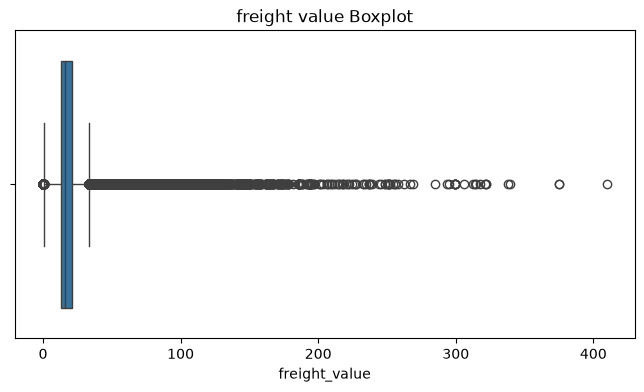

In [305]:
plt.figure(figsize=(8,4))
sns.boxplot(
    x=order_items["freight_value"]
)
plt.title("freight value Boxplot")
plt.show()

In [306]:
Q1 = order_items["freight_value"].quantile(0.25)
Q3 = order_items["freight_value"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: 0.9750000000000032
Upper Bound: 33.254999999999995


In [307]:
order_items["freight_value"] = order_items["freight_value"].clip(
    lower=lower,
    upper=upper
)

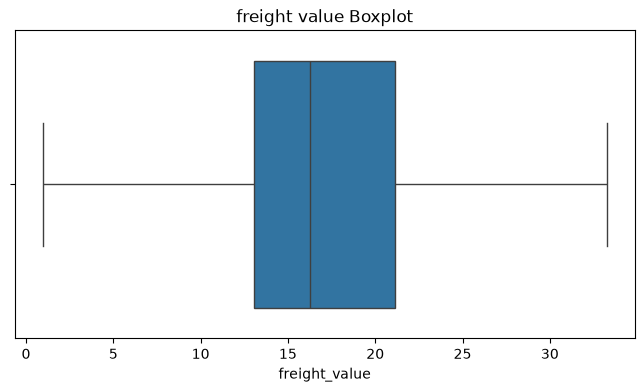

In [308]:
plt.figure(figsize=(8,4))
sns.boxplot(
    x=order_items["freight_value"]
)
plt.title("freight value Boxplot")
plt.show()

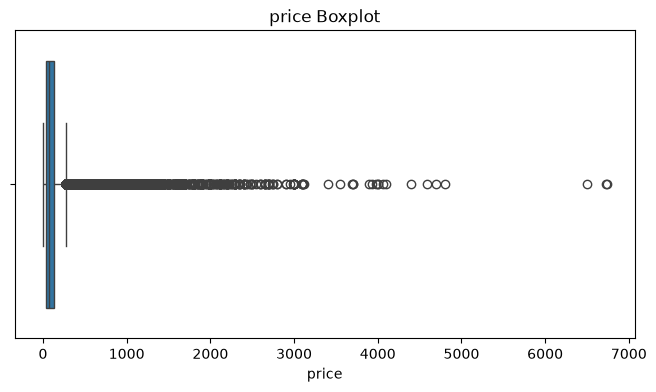

In [309]:
plt.figure(figsize=(8,4))
sns.boxplot(
    x=order_items["price"]
)
plt.title("price Boxplot")
plt.show()

In [310]:
Q1 = order_items["price"].quantile(0.25)
Q3 = order_items["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: -102.6
Upper Bound: 277.4


In [311]:
order_items["price"] = order_items["price"].clip(
    lower=lower,
    upper=upper
)

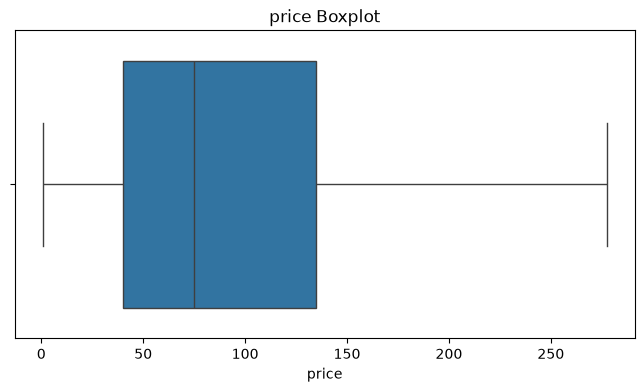

In [312]:
plt.figure(figsize=(8,4))
sns.boxplot(
    x=order_items["price"]
)
plt.title("price Boxplot")
plt.show()

In [313]:
customer_orders_items=pd.merge(order_items,customer_orders,on="order_id",how="left")

In [314]:
customer_orders_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013.0,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775.0,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661.0,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952.0,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226.0,varzea paulista,SP


In [315]:
customer_orders_items.shape

(112650, 18)

In [316]:
customer_orders_items.duplicated().sum()

np.int64(0)

In [317]:
customer_orders_items.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                        24
order_status                       24
order_purchase_timestamp           24
order_approved_at                  24
order_delivered_carrier_date     1216
order_delivered_customer_date    2470
order_estimated_delivery_date      24
customer_unique_id                 24
customer_zip_code_prefix           24
customer_city                      24
customer_state                     24
dtype: int64

In [318]:
customer_orders_items[
    customer_orders_items["customer_id"].isnull()
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
5841,0d3268bad9b086af767785e3f0fc0133,1,ec165cd31c50585786ffda6feff5d0a6,8bdd8e3fd58bafa48af76b2c5fd71974,2018-07-05 21:29:54,188.99,15.630,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
8204,12a95a3c06dbaec84bcfb0e2da5d228a,1,c6dd917a0be2a704582055949915ab32,7a67c85e85bb2ce8582c35f2203ad736,2017-02-21 12:05:55,79.99,15.770,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
14472,20edc82cf5400ce95e1afacc25798b31,1,55bfa0307d7a46bed72c492259921231,343e716476e3748b069f980efbaa294e,2018-07-03 16:29:30,45.90,9.070,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
18554,2aa91108853cecb43c84a5dc5b277475,1,44c2baf621113fa7ac95fa06b4afbc68,3f2af2670e104d1bcb54022274daeac5,2017-10-18 10:07:16,179.00,14.980,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
19005,2babbb4b15e6d2dfe95e2de765c97bce,1,c6dd917a0be2a704582055949915ab32,7a67c85e85bb2ce8582c35f2203ad736,2017-02-22 16:15:03,79.99,26.820,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
19642,2d1e2d5bf4dc7227b3bfebb81328c15f,1,a50acd33ba7a8da8e9db65094fa990a4,8581055ce74af1daba164fdbd55a40de,2017-12-04 17:56:40,117.30,17.530,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
19838,2d858f451373b04fb5c984a1cc2defaf,1,30b5b5635a79548a48d04162d971848f,f9bbdd976532d50b7816d285a22bd01e,2017-06-04 23:30:16,179.00,15.000,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
20393,2ebdfc4f15f23b91474edf87475f108e,1,e7d5464b94c9a5963f7c686fc80145ad,58f1a6197ed863543e0136bdedb3fce2,2018-07-05 17:15:12,139.00,19.070,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
20473,2eecb0d85f281280f79fa00f9cec1a95,1,4fd676d9c4723d475026e40aeae56957,5fd924b4836098a5be0ecf81ba054ce0,2017-02-21 16:21:55,135.00,19.230,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
26393,3c0b8706b065f9919d0505d3b3343881,1,db8ed3d08891d16a2438a67ab3acb740,004c9cd9d87a3c30c522c48c4fc07416,2017-02-22 14:53:27,133.99,23.200,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [319]:
customer_orders_items = customer_orders_items.dropna(
    subset=["customer_id"]
)

In [320]:
customer_orders_items.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1192
order_delivered_customer_date    2446
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
dtype: int64

In [321]:
customer_orders_items[
    customer_orders_items["order_delivered_customer_date"].isnull()
]["order_status"].value_counts()

order_status
shipped        1185
canceled        535
invoiced        359
processing      357
unavailable       7
approved          3
Name: count, dtype: int64

In [322]:
customer_orders_items[
    customer_orders_items["order_delivered_carrier_date"].isnull()
]["order_status"].value_counts()

order_status
canceled       466
invoiced       359
processing     357
unavailable      7
approved         3
Name: count, dtype: int64

In [323]:
products = pd.read_csv("olist_products_dataset.csv")
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [324]:
products.shape

(32951, 9)

In [325]:
products.duplicated().sum()

np.int64(0)

In [326]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [327]:
products.dtypes

product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [328]:
products["product_category_name"] = products["product_category_name"].fillna("mode")

In [329]:
median_value = products["product_name_lenght"].median()
products["product_name_lenght"] = products["product_name_lenght"].fillna(median_value)

In [330]:
products["product_description_lenght"] = products[
    "product_description_lenght"
].fillna(
    products["product_description_lenght"].median()
)

In [331]:
products["product_photos_qty"] = products[
    "product_photos_qty"
].fillna(
    products["product_photos_qty"].median()
)

In [332]:
products["product_weight_g"] = products[
    "product_weight_g"
].fillna(
    products["product_weight_g"].median()
)

In [333]:
products["product_length_cm"] = products[
    "product_length_cm"
].fillna(
    products["product_length_cm"].median()
)

In [334]:
products["product_height_cm"] = products[
    "product_height_cm"
].fillna(
    products["product_height_cm"].median()
)

In [335]:
products["product_width_cm"] = products[
    "product_width_cm"
].fillna(
    products["product_width_cm"].median()
)

In [336]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

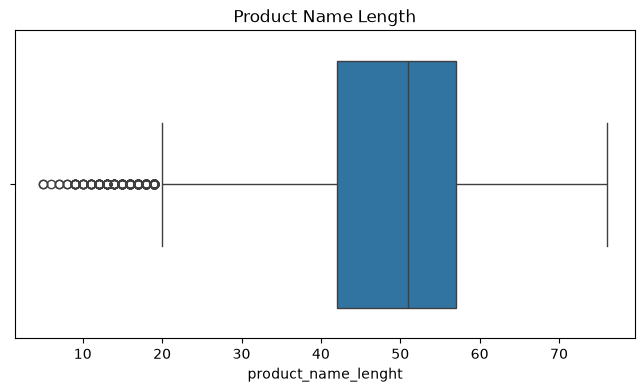

In [337]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_name_lenght"])
plt.title("Product Name Length")
plt.show()

In [338]:
Q1 = products["product_name_lenght"].quantile(0.25)
Q3 = products["product_name_lenght"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

19.5 79.5


In [339]:
products["product_name_lenght"] = products["product_name_lenght"].clip(lower, upper)

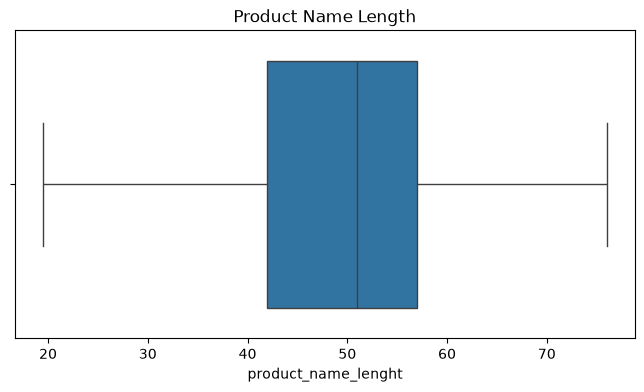

In [340]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_name_lenght"])
plt.title("Product Name Length")
plt.show()

In [341]:
products.drop_duplicates(subset=["product_id"], inplace=True)

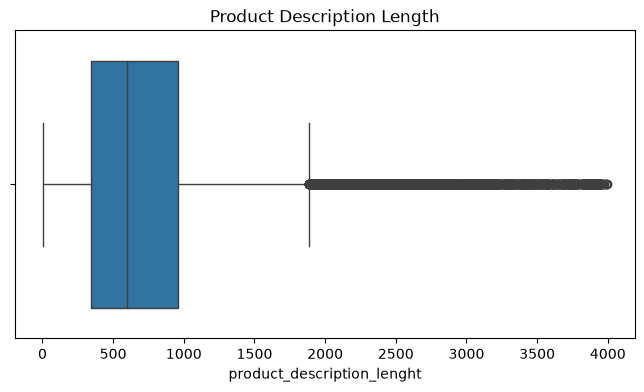

In [342]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_description_lenght"])
plt.title("Product Description Length")
plt.show()

In [343]:
Q1 = products["product_description_lenght"].quantile(0.25)
Q3 = products["product_description_lenght"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-581.5 1886.5


In [344]:
products["product_description_lenght"] = products["product_description_lenght"].clip(lower, upper)

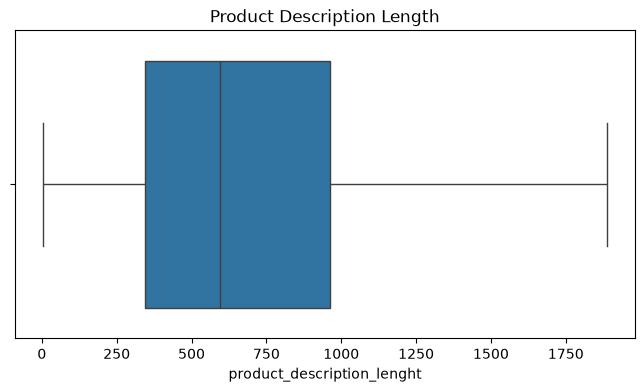

In [345]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_description_lenght"])
plt.title("Product Description Length")
plt.show()

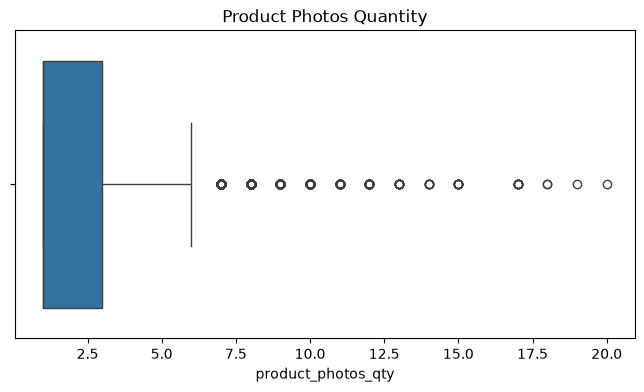

In [346]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_photos_qty"])
plt.title("Product Photos Quantity")
plt.show()

In [347]:
Q1 = products["product_photos_qty"].quantile(0.25)
Q3 = products["product_photos_qty"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-2.0 6.0


In [348]:
products["product_photos_qty"] = products["product_photos_qty"].clip(lower, upper)

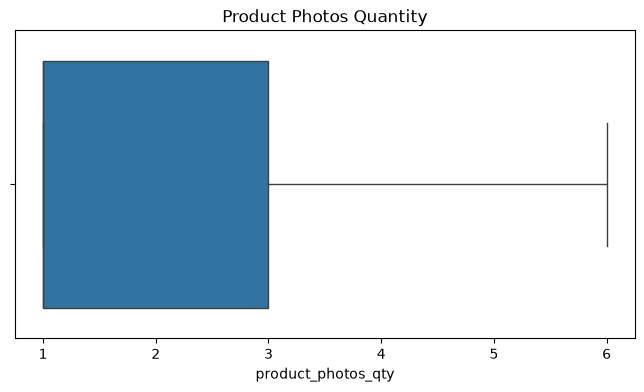

In [349]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_photos_qty"])
plt.title("Product Photos Quantity")
plt.show()

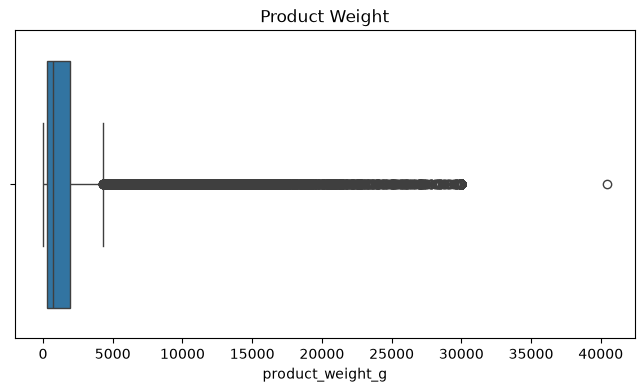

In [350]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_weight_g"])
plt.title("Product Weight")
plt.show()

In [351]:
Q1 = products["product_weight_g"].quantile(0.25)
Q3 = products["product_weight_g"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-2100.0 4300.0


In [352]:
products["product_weight_g"] = products["product_weight_g"].clip(lower, upper)

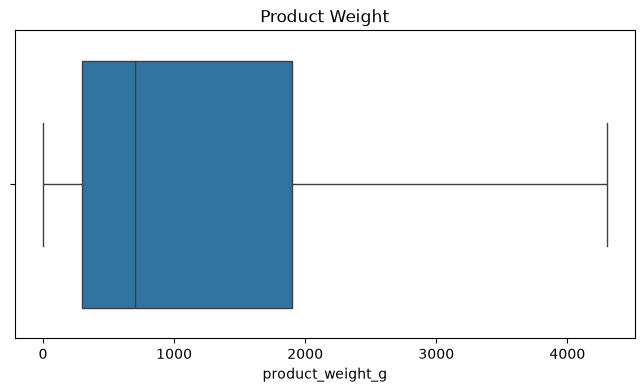

In [353]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_weight_g"])
plt.title("Product Weight")
plt.show()

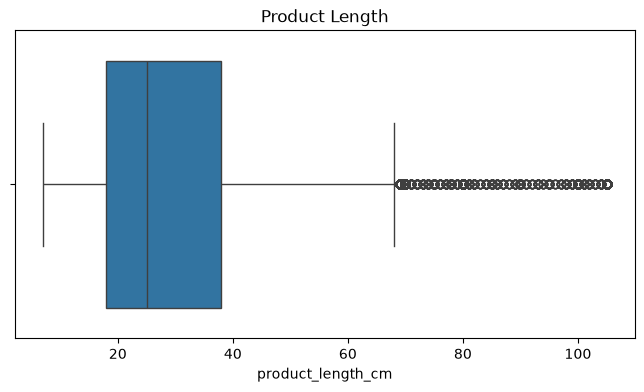

In [354]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_length_cm"])
plt.title("Product Length")
plt.show()

In [355]:
Q1 = products["product_length_cm"].quantile(0.25)
Q3 = products["product_length_cm"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-12.0 68.0


In [356]:
products["product_length_cm"] = products["product_length_cm"].clip(lower, upper)

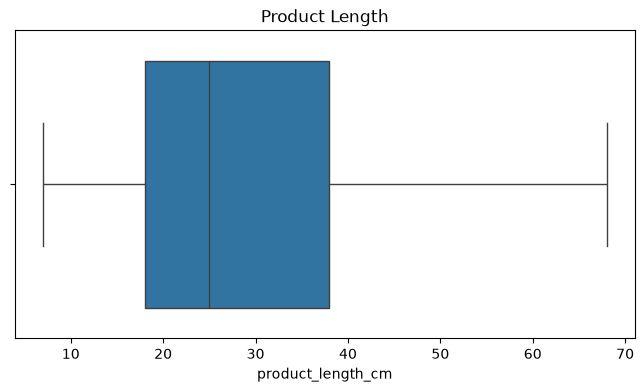

In [357]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_length_cm"])
plt.title("Product Length")
plt.show()

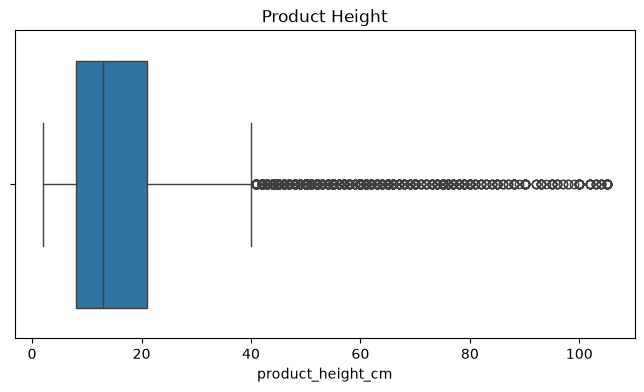

In [358]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_height_cm"])
plt.title("Product Height")
plt.show()

In [359]:
Q1 = products["product_height_cm"].quantile(0.25)
Q3 = products["product_height_cm"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-11.5 40.5


In [360]:
products["product_height_cm"] = products["product_height_cm"].clip(lower, upper)

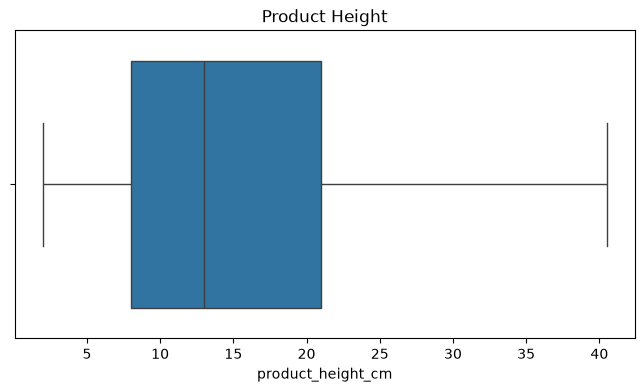

In [361]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_height_cm"])
plt.title("Product Height")
plt.show()

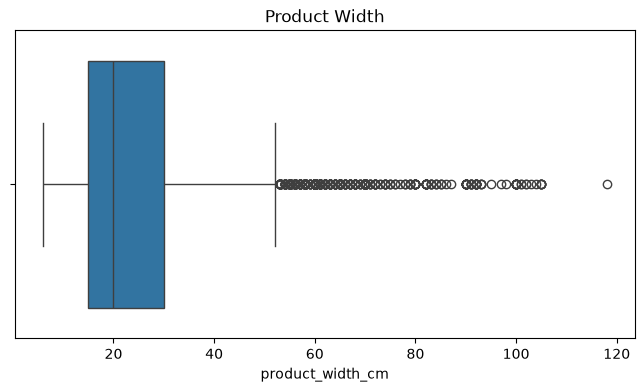

In [362]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_width_cm"])
plt.title("Product Width")
plt.show()

In [363]:
Q1 = products["product_width_cm"].quantile(0.25)
Q3 = products["product_width_cm"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-7.5 52.5


In [364]:
products["product_width_cm"] = products["product_width_cm"].clip(lower, upper)

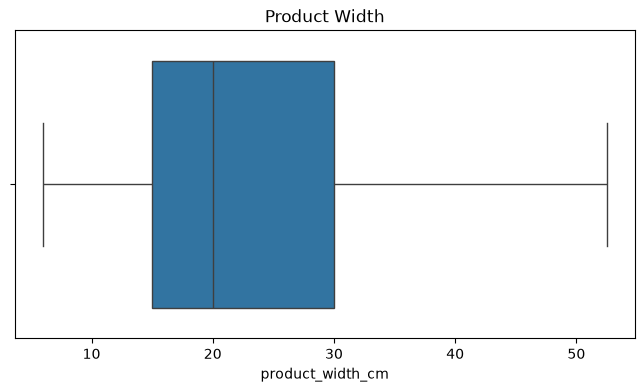

In [365]:
plt.figure(figsize=(8,4))
sns.boxplot(x=products["product_width_cm"])
plt.title("Product Width")
plt.show()

In [366]:
customer_orders_items_products = pd.merge(
    customer_orders_items,
    products,
    on="product_id",
    how="left"
)
customer_orders_items_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,4300.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [367]:
customer_orders_items_products.shape

(112626, 26)

In [368]:
customer_orders_items_products.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1192
order_delivered_customer_date    2446
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
dtype: int64

In [369]:
customer_orders_items_products.duplicated().sum()

np.int64(0)

In [370]:
category_translation = pd.read_csv("product_category_name_translation.csv")
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [371]:
category_translation.shape

(71, 2)

In [372]:
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [373]:
category_translation.duplicated().sum()

np.int64(0)

In [374]:
customer_orders_full = pd.merge(
    customer_orders_items_products,
    category_translation,
    on="product_category_name",
    how="left"
)
customer_orders_full.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,SP,pet_shop,56.0,239.0,2.0,4300.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [375]:
customer_orders_full.shape

(112626, 27)

In [376]:
customer_orders_full.duplicated().sum()

np.int64(0)

In [377]:
customer_orders_full.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1192
order_delivered_customer_date    2446
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [378]:
customer_orders_full[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].isnull().sum()

product_category_name               0
product_category_name_english    1626
dtype: int64

In [379]:
customer_orders_full["product_category_name_english"] = (customer_orders_full["product_category_name_english"].fillna("mode"))

In [380]:
customer_orders_full.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1192
order_delivered_customer_date    2446
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [381]:
category_translation.drop_duplicates(
    subset=["product_category_name"],
    inplace=True
)

In [382]:
customer_orders_items_products_translation = pd.merge(
    customer_orders_items_products,
    category_translation,
    on="product_category_name",
    how="left"
)
customer_orders_items_products_translation.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,SP,pet_shop,56.0,239.0,2.0,4300.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [383]:
customer_orders_items_products_translation.shape

(112626, 27)

In [384]:
customer_orders_items_products_translation.duplicated().sum()

np.int64(0)

In [385]:
customer_orders_items_products_translation.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1192
order_delivered_customer_date    2446
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [386]:
customer_orders_items_products_translation[
    "product_category_name_english"
] = customer_orders_items_products_translation[
    "product_category_name_english"
].fillna("mode")

In [387]:
customer_orders_items_products_translation.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1192
order_delivered_customer_date    2446
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [388]:
payments = pd.read_csv("olist_order_payments_dataset.csv")
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [389]:
payments.shape

(103886, 5)

In [390]:
payments.duplicated().sum()

np.int64(0)

In [391]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [392]:
payments[
    payments["payment_value"] <= 0
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [393]:
payments = payments[payments["payment_value"] > 0]

In [394]:
payments.tail(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
103876,0872d0faafe0cb56e6f2c594cca1522c,1,credit_card,2,127.92
103877,3531718b24dfd5022fb0d101e10e33b9,1,credit_card,1,194.11
103878,2e3d96522c8c378d4135c12a65c977aa,1,credit_card,4,47.62
103879,c45067032fd84f4cf408730ff5205568,1,credit_card,2,198.94
103880,7159096c5aa9be77f7f0c26c01ee9793,1,credit_card,4,280.65
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54
103885,28bbae6599b09d39ca406b747b6632b1,1,boleto,1,191.58


In [395]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [396]:
payments.duplicated().sum()

np.int64(0)

In [397]:
payments["order_id"].duplicated().sum()

np.int64(4440)

In [398]:
customer_orders_items_products_payments = pd.merge(
    customer_orders_items_products_translation,
    payments,
    on="order_id",
    how="left"
)
customer_orders_items_products_payments.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,4.0,650.0,28.0,9.0,14.0,cool_stuff,1.0,credit_card,2.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2.0,4300.0,50.0,30.0,40.0,pet_shop,1.0,credit_card,3.0,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2.0,3050.0,33.0,13.0,33.0,furniture_decor,1.0,credit_card,5.0,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,1.0,200.0,16.0,10.0,15.0,perfumery,1.0,credit_card,2.0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,1.0,3750.0,35.0,40.0,30.0,garden_tools,1.0,credit_card,3.0,218.04


In [399]:
customer_orders_items_products_payments.shape

(117574, 31)

In [400]:
customer_orders_items_products_payments.duplicated().sum()

np.int64(0)

In [401]:
customer_orders_items_products_payments.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1243
order_delivered_customer_date    2557
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [402]:
customer_orders_items_products_payments.dtypes

order_id                                    str
order_item_id                             int64
product_id                                  str
seller_id                                   str
shipping_limit_date                         str
price                                   float64
freight_value                           float64
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                           str
order_delivered_carrier_date                str
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date               str
customer_unique_id                          str
customer_zip_code_prefix                float64
customer_city                               str
customer_state                              str
product_category_name                       str
product_name_lenght                     float64
product_description_lenght              

In [403]:
missing_payment = customer_orders_items_products_payments[
    customer_orders_items_products_payments["payment_value"].isnull()
]
missing_payment

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
88069,bfbd0f9bdef84302105ad712db648a6c,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,...,1.0,1000.0,16.0,16.0,16.0,health_beauty,NaN,NaN,NaN,NaN
88070,bfbd0f9bdef84302105ad712db648a6c,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,...,1.0,1000.0,16.0,16.0,16.0,health_beauty,NaN,NaN,NaN,NaN
88071,bfbd0f9bdef84302105ad712db648a6c,3,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,...,1.0,1000.0,16.0,16.0,16.0,health_beauty,NaN,NaN,NaN,NaN


In [404]:
missing_payment["order_status"].value_counts()

order_status
delivered    3
Name: count, dtype: int64

In [405]:
missing_payment[
    [
        "order_id",
        "order_status",
        "price",
        "freight_value",
        "payment_value",
        "payment_type"
    ]
]

,order_id,order_status,price,freight_value,payment_value,payment_type
88069,bfbd0f9bdef84302105ad712db648a6c,delivered,44.99,2.83,NaN,NaN
88070,bfbd0f9bdef84302105ad712db648a6c,delivered,44.99,2.83,NaN,NaN
88071,bfbd0f9bdef84302105ad712db648a6c,delivered,44.99,2.83,NaN,NaN


In [406]:
payments[
    payments["order_id"].isin(
        missing_payment["order_id"]
    )
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [407]:
customer_orders_items_products_payments[
    "payment_type"
] = customer_orders_items_products_payments[
    "payment_type"
].fillna("mode")

In [408]:
customer_orders_items_products_payments[
    "payment_installments"
] = customer_orders_items_products_payments[
    "payment_installments"
].fillna(0)

In [409]:
customer_orders_items_products_payments[
    "payment_value"
] = customer_orders_items_products_payments[
    "payment_value"
].fillna(
    customer_orders_items_products_payments["price"] +
    customer_orders_items_products_payments["freight_value"]
)

In [410]:
customer_orders_items_products_payments[
    "payment_sequential"
] = customer_orders_items_products_payments[
    "payment_sequential"
].fillna(1)

In [411]:
customer_orders_items_products_payments.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1243
order_delivered_customer_date    2557
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [412]:
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [413]:
reviews.shape

(99224, 7)

In [414]:
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

In [415]:
reviews.duplicated().sum()

np.int64(0)

In [416]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [417]:
reviews.dtypes

review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

In [418]:
reviews["review_comment_title"] = (
    reviews["review_comment_title"]
    .fillna("No Title")
)

In [419]:
reviews["review_comment_message"] = (
    reviews["review_comment_message"]
    .fillna("No Comment")
)

In [420]:
reviews.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [421]:
customer_orders_items_products_payments_reviews = pd.merge(
    customer_orders_items_products_payments,
    reviews,
    on="order_id",
    how="left"
)
customer_orders_items_products_payments_reviews.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,1.0,credit_card,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,No Title,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,1.0,credit_card,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,No Title,No Comment,2017-05-13,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,1.0,credit_card,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,No Title,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,1.0,credit_card,2.0,25.78,f4028d019cb58564807486a6aaf33817,4.0,No Title,No Comment,2018-08-15,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,1.0,credit_card,3.0,218.04,940144190dcba6351888cafa43f3a3a5,5.0,No Title,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59


In [422]:
customer_orders_items_products_payments_reviews.shape

(118280, 37)

In [423]:
customer_orders_items_products_payments_reviews.duplicated().sum()

np.int64(0)

In [424]:
customer_orders_items_products_payments_reviews.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1252
order_delivered_customer_date    2578
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [425]:
customer_orders_items_products_payments_reviews[
    customer_orders_items_products_payments_reviews["review_score"].isnull()
]["order_status"].value_counts()

order_status
delivered     861
shipped        88
canceled       17
processing      6
invoiced        6
Name: count, dtype: int64

In [426]:
customer_orders_items_products_payments_reviews["review_score"] = (
    customer_orders_items_products_payments_reviews["review_score"]
    .fillna(0)
)

In [427]:
customer_orders_items_products_payments_reviews.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1252
order_delivered_customer_date    2578
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [428]:
customer_orders_items_products_payments_reviews[
    customer_orders_items_products_payments_reviews["review_id"].isnull()
]["order_status"].value_counts()

order_status
delivered     861
shipped        88
canceled       17
processing      6
invoiced        6
Name: count, dtype: int64

In [429]:
customer_orders_items_products_payments_reviews["review_id"] = customer_orders_items_products_payments_reviews["review_id"].fillna("No Review")

In [430]:
customer_orders_items_products_payments_reviews["review_comment_title"] = (customer_orders_items_products_payments_reviews["review_comment_title"].fillna("No Title"))

In [431]:
customer_orders_items_products_payments_reviews["review_comment_message"] = (customer_orders_items_products_payments_reviews["review_comment_message"].fillna("No Comment"))

In [432]:
customer_orders_items_products_payments_reviews["has_review"] = customer_orders_items_products_payments_reviews["review_score"].apply(lambda x: 1 if x > 0 else 0)

In [433]:
customer_orders_items_products_payments_reviews.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1252
order_delivered_customer_date    2578
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [434]:
sellers = pd.read_csv("olist_sellers_dataset.csv")
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [435]:
sellers.shape

(3095, 4)

In [436]:
sellers.duplicated().sum()

np.int64(0)

In [437]:
sellers.drop_duplicates(inplace=True)

In [438]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [439]:
sellers["seller_id"].duplicated().sum()

np.int64(0)

In [440]:
customer_orders_full = pd.merge(
    customer_orders_items_products_payments_reviews,
    sellers,
    on="seller_id",
    how="left"
)
customer_orders_full.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,has_review,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,97ca439bc427b48bc1cd7177abe71365,5.0,No Title,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03,1,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,7b07bacd811c4117b742569b04ce3580,4.0,No Title,No Comment,2017-05-13,2017-05-15 11:34:13,1,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,0c5b33dea94867d1ac402749e5438e8b,5.0,No Title,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31,1,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,f4028d019cb58564807486a6aaf33817,4.0,No Title,No Comment,2018-08-15,2018-08-15 16:39:01,1,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,940144190dcba6351888cafa43f3a3a5,5.0,No Title,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59,1,87900,loanda,PR


In [441]:
customer_orders_full.shape

(118280, 41)

In [442]:
customer_orders_full.duplicated().sum()

np.int64(0)

In [443]:
customer_orders_full.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1252
order_delivered_customer_date    2578
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [444]:
customer_orders_full[
    [
        "seller_id",
        "seller_city",
        "seller_state"
    ]
].isnull().sum()

seller_id       0
seller_city     0
seller_state    0
dtype: int64

In [445]:
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [446]:
geolocation.shape

(1000163, 5)

In [447]:
geolocation.duplicated().sum()

np.int64(261831)

In [448]:
geolocation.drop_duplicates(inplace=True)

In [449]:
geolocation.duplicated().sum()

np.int64(0)

In [450]:
geolocation["geolocation_zip_code_prefix"].duplicated().sum()

np.int64(719317)

In [451]:
geolocation.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [452]:
geolocation_clean = geolocation.drop_duplicates()

In [453]:
geo_summary = (
    geolocation_clean
    .groupby("geolocation_zip_code_prefix")
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean",
        "geolocation_city": "first",
        "geolocation_state": "first"
    })
    .reset_index()
)

In [454]:
geo_summary.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.550227,-46.634039,sao paulo,SP
1,1002,-23.547657,-46.634991,sao paulo,SP
2,1003,-23.549000,-46.635582,sao paulo,SP
3,1004,-23.549829,-46.634792,sao paulo,SP
4,1005,-23.549547,-46.636406,sao paulo,SP


In [455]:
geo_summary.rename(
    columns={
        "geolocation_zip_code_prefix":
        "customer_zip_code_prefix"
    },
    inplace=True
)

In [456]:
customer_orders_full_geo = pd.merge(
    customer_orders_full,
    geo_summary,
    on="customer_zip_code_prefix",
    how="left"
)
customer_orders_full_geo.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_creation_date,review_answer_timestamp,has_review,seller_zip_code_prefix,seller_city,seller_state,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-21,2017-09-22 10:57:03,1,27277,volta redonda,SP,-21.763186,-41.310265,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-13,2017-05-15 11:34:13,1,3471,sao paulo,SP,-20.222506,-50.898951,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-01-23,2018-01-23 16:06:31,1,37564,borda da mata,MG,-19.869998,-44.593059,pará de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-15,2018-08-15 16:39:01,1,14403,franca,SP,-23.105968,-46.590277,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-02,2017-03-03 10:54:59,1,87900,loanda,PR,-23.243402,-46.827614,varzea paulista,SP


In [457]:
customer_orders_full_geo.shape

(118280, 45)

In [458]:
customer_orders_full_geo.duplicated().sum()

np.int64(0)

In [459]:
customer_orders_full_geo.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1252
order_delivered_customer_date    2578
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [460]:
customer_orders_full_geo.dtypes

order_id                                    str
order_item_id                             int64
product_id                                  str
seller_id                                   str
shipping_limit_date                         str
price                                   float64
freight_value                           float64
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                           str
order_delivered_carrier_date                str
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date               str
customer_unique_id                          str
customer_zip_code_prefix                float64
customer_city                               str
customer_state                              str
product_category_name                       str
product_name_lenght                     float64
product_description_lenght              

In [461]:
customer_orders_full_geo["geolocation_city"] = customer_orders_full_geo["geolocation_city"].fillna("Unknown")

In [462]:
customer_orders_full_geo["geolocation_state"] = customer_orders_full_geo["geolocation_state"].fillna("Unknown")

In [463]:
customer_orders_full_geo.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1252
order_delivered_customer_date    2578
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

# FEATURE ENGINEERING

In [464]:
final_df = customer_orders_full_geo.copy()

In [465]:
final_df["order_purchase_timestamp"] = pd.to_datetime(
    final_df["order_purchase_timestamp"]
)
final_df["order_delivered_customer_date"] = pd.to_datetime(
    final_df["order_delivered_customer_date"]
)
final_df["delivery_time"] = (
    final_df["order_delivered_customer_date"] -
    final_df["order_purchase_timestamp"]
).dt.days

In [466]:
final_df["delivery_time"].describe()

count    115702.000000
mean         12.022212
std           9.454957
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time, dtype: float64

In [507]:
final_df["order_delivered_carrier_date"] = pd.to_datetime(
    final_df["order_delivered_carrier_date"]
)

In [468]:
final_df["order_approved_at"] = pd.to_datetime(
    final_df["order_approved_at"]
)
final_df["order_processing_time"] = (
    final_df["order_approved_at"] -
    final_df["order_purchase_timestamp"]
).dt.total_seconds()/3600

In [469]:
customer_ltv = (
    final_df.groupby("customer_unique_id")["payment_value"]
      .sum()
      .reset_index()
      .rename(columns={"payment_value":"customer_lifetime_value"})
)
final_df = final_df.merge(customer_ltv,on="customer_unique_id",how="left")
final_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,seller_city,seller_state,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,delivery_time,shipping_duration,order_processing_time,customer_lifetime_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,volta redonda,SP,-21.763186,-41.310265,campos dos goytacazes,RJ,7.0,1.0,0.775833,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,sao paulo,SP,-20.222506,-50.898951,santa fe do sul,SP,16.0,8.0,0.201944,284.56
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,borda da mata,MG,-19.869998,-44.593059,pará de minas,MG,7.0,6.0,0.249722,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,franca,SP,-23.105968,-46.590277,atibaia,SP,6.0,4.0,0.161944,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,loanda,PR,-23.243402,-46.827614,varzea paulista,SP,25.0,13.0,0.206111,218.04


In [470]:
final_df["shipping_duration"] = (
    final_df["order_delivered_customer_date"] -
    final_df["order_delivered_carrier_date"]
).dt.days

In [471]:
final_df["payment_type"].value_counts()

payment_type
credit_card    87250
boleto         23003
voucher         6326
debit_card      1698
mode               3
Name: count, dtype: int64

In [472]:
order_value = (
    final_df.groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
    .rename(columns={"payment_value": "total_order_value"})
)
final_df = final_df.merge(
    order_value,
    on="order_id",
    how="left"
)
final_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,seller_state,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,delivery_time,shipping_duration,order_processing_time,customer_lifetime_value,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,SP,-21.763186,-41.310265,campos dos goytacazes,RJ,7.0,1.0,0.775833,72.19,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,SP,-20.222506,-50.898951,santa fe do sul,SP,16.0,8.0,0.201944,284.56,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,MG,-19.869998,-44.593059,pará de minas,MG,7.0,6.0,0.249722,216.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,SP,-23.105968,-46.590277,atibaia,SP,6.0,4.0,0.161944,25.78,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,PR,-23.243402,-46.827614,varzea paulista,SP,25.0,13.0,0.206111,218.04,218.04


In [508]:
final_df["order_processing_time"] = (
    final_df["order_approved_at"] -
    final_df["order_purchase_timestamp"]
).dt.total_seconds()/3600

In [473]:
order_value = (
    final_df.groupby("order_id")["payment_value"]
    .sum()
)

In [474]:
final_df[["order_id", "order_item_id", "payment_value", "total_order_value"]].head(20)

,order_id,order_item_id,payment_value,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,72.19,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,259.83,259.83
2,000229ec398224ef6ca0657da4fc703e,1,216.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,25.78,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,218.04,218.04
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,34.59,34.59
6,00054e8431b9d7675808bcb819fb4a32,1,31.75,31.75
7,000576fe39319847cbb9d288c5617fa6,1,880.75,880.75
8,0005a1a1728c9d785b8e2b08b904576c,1,157.60,157.60
9,0005f50442cb953dcd1d21e1fb923495,1,65.39,65.39


In [475]:
order_value = (
    final_df[["order_id", "payment_value"]]
    .drop_duplicates()
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
    .rename(columns={"payment_value": "total_order_value"})
)

In [476]:
final_df["total_order_value"].describe()

count    118280.000000
mean        356.008518
std        1596.028211
min           9.590000
25%          67.880000
50%         127.000000
75%         258.672500
max      109312.640000
Name: total_order_value, dtype: float64

In [477]:
final_df["total_order_value"].sort_values(ascending=False).head(10)

1700     109312.64
1706     109312.64
1699     109312.64
1705     109312.64
1704     109312.64
1703     109312.64
1702     109312.64
1701     109312.64
78936     45256.00
78935     45256.00
Name: total_order_value, dtype: float64

In [478]:
Q1 = final_df["total_order_value"].quantile(0.25)
Q3 = final_df["total_order_value"].quantile(0.75)
IQR = Q3 - Q1
filtered = final_df[
    (final_df["total_order_value"] >= Q1 - 1.5 * IQR) &
    (final_df["total_order_value"] <= Q3 + 1.5 * IQR)
]

In [479]:
avg_price = (
    final_df.groupby("product_id")["price"]
    .mean()
    .reset_index()
    .rename(columns={"price": "average_product_price"})
)
final_df = final_df.merge(
    avg_price,
    on="product_id",
    how="left"
)
final_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,delivery_time,shipping_duration,order_processing_time,customer_lifetime_value,total_order_value,average_product_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,-21.763186,-41.310265,campos dos goytacazes,RJ,7.0,1.0,0.775833,72.19,72.19,58.627273
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,-20.222506,-50.898951,santa fe do sul,SP,16.0,8.0,0.201944,284.56,259.83,239.900000
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,-19.869998,-44.593059,pará de minas,MG,7.0,6.0,0.249722,216.87,216.87,199.000000
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,-23.105968,-46.590277,atibaia,SP,6.0,4.0,0.161944,25.78,25.78,12.990000
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,-23.243402,-46.827614,varzea paulista,SP,25.0,13.0,0.206111,218.04,218.04,202.400000


In [480]:
avg_review = (
    final_df.groupby("product_id")["review_score"]
    .mean()
    .reset_index()
    .rename(columns={"review_score": "average_review_score"})
)
final_df = final_df.merge(
    avg_review,
    on="product_id",
    how="left"
)
final_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,geolocation_lng,geolocation_city,geolocation_state,delivery_time,shipping_duration,order_processing_time,customer_lifetime_value,total_order_value,average_product_price,average_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,-41.310265,campos dos goytacazes,RJ,7.0,1.0,0.775833,72.19,72.19,58.627273,3.818182
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,-50.898951,santa fe do sul,SP,16.0,8.0,0.201944,284.56,259.83,239.900000,4.000000
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,-44.593059,pará de minas,MG,7.0,6.0,0.249722,216.87,216.87,199.000000,4.333333
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,-46.590277,atibaia,SP,6.0,4.0,0.161944,25.78,25.78,12.990000,4.000000
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,-46.827614,varzea paulista,SP,25.0,13.0,0.206111,218.04,218.04,202.400000,3.833333


In [481]:
purchase_count = (
    final_df.groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
    .rename(columns={"order_id": "customer_purchase_count"})
)
final_df = final_df.merge(
    purchase_count,
    on="customer_unique_id",
    how="left"
)
final_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,geolocation_city,geolocation_state,delivery_time,shipping_duration,order_processing_time,customer_lifetime_value,total_order_value,average_product_price,average_review_score,customer_purchase_count
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,campos dos goytacazes,RJ,7.0,1.0,0.775833,72.19,72.19,58.627273,3.818182,1
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,santa fe do sul,SP,16.0,8.0,0.201944,284.56,259.83,239.900000,4.000000,2
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,pará de minas,MG,7.0,6.0,0.249722,216.87,216.87,199.000000,4.333333,1
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,atibaia,SP,6.0,4.0,0.161944,25.78,25.78,12.990000,4.000000,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,varzea paulista,SP,25.0,13.0,0.206111,218.04,218.04,202.400000,3.833333,1


In [482]:
seller_score = (
    final_df.groupby("seller_id")["review_score"]
    .mean()
    .reset_index()
    .rename(columns={"review_score": "seller_performance_score"})
)
final_df = final_df.merge(
    seller_score,
    on="seller_id",
    how="left"
)
final_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,geolocation_state,delivery_time,shipping_duration,order_processing_time,customer_lifetime_value,total_order_value,average_product_price,average_review_score,customer_purchase_count,seller_performance_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,RJ,7.0,1.0,0.775833,72.19,72.19,58.627273,3.818182,1,3.950000
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,SP,16.0,8.0,0.201944,284.56,259.83,239.900000,4.000000,2,3.724359
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,MG,7.0,6.0,0.249722,216.87,216.87,199.000000,4.333333,1,3.785714
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,SP,6.0,4.0,0.161944,25.78,25.78,12.990000,4.000000,1,3.750000
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,SP,25.0,13.0,0.206111,218.04,218.04,202.400000,3.833333,1,3.538462


In [483]:
revenue_customer = (
    final_df.groupby("customer_unique_id")["payment_value"]
    .sum()
    .reset_index()
    .rename(columns={"payment_value": "revenue_per_customer"})
)
final_df = final_df.merge(
    revenue_customer,
    on="customer_unique_id",
    how="left"
)
final_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,delivery_time,shipping_duration,order_processing_time,customer_lifetime_value,total_order_value,average_product_price,average_review_score,customer_purchase_count,seller_performance_score,revenue_per_customer
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,7.0,1.0,0.775833,72.19,72.19,58.627273,3.818182,1,3.950000,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,16.0,8.0,0.201944,284.56,259.83,239.900000,4.000000,2,3.724359,284.56
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,7.0,6.0,0.249722,216.87,216.87,199.000000,4.333333,1,3.785714,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,6.0,4.0,0.161944,25.78,25.78,12.990000,4.000000,1,3.750000,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,25.0,13.0,0.206111,218.04,218.04,202.400000,3.833333,1,3.538462,218.04


In [569]:
final_df["order_purchase_timestamp"] = pd.to_datetime(
    final_df["order_purchase_timestamp"],
    errors="coerce"
)
final_df["order_estimated_delivery_date"] = pd.to_datetime(
    final_df["order_estimated_delivery_date"],
    errors="coerce"
)

In [570]:
final_df["estimated_delivery_days"] = (
    final_df["order_estimated_delivery_date"] -
    final_df["order_purchase_timestamp"]
).dt.days

In [571]:
final_df["delivery_status"] = np.where(
    final_df["delivery_time"] <= final_df["estimated_delivery_days"],
    "On Time",
    "Delayed"
)

In [484]:
final_df["purchase_month"] = (
    final_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [485]:
monthly_sales = (
    final_df.groupby("purchase_month")["payment_value"]
    .sum()
    .reset_index()
)
monthly_sales.head()

,purchase_month,payment_value
0,2016-09,490.98
1,2016-10,74353.46
2,2016-12,19.62
3,2017-01,189455.09
4,2017-02,344314.28


In [509]:
final_df["repeat_customer"] = np.where(
    final_df["customer_purchase_count"] > 1,
    "Yes",
    "No"
)

In [486]:
seller_sales = (
    final_df.groupby("seller_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
seller_sales["Seller"] = [
    f"Seller {i}" for i in range(1, len(seller_sales) + 1)
]
seller_sales.head()

,seller_id,payment_value,Seller
0,7c67e1448b00f6e969d365cea6b010ab,512645.19,Seller 1
1,1025f0e2d44d7041d6cf58b6550e0bfa,312456.49,Seller 2
2,4a3ca9315b744ce9f8e9374361493884,306138.80,Seller 3
3,1f50f920176fa81dab994f9023523100,291918.98,Seller 4
4,53243585a1d6dc2643021fd1853d8905,284903.08,Seller 5


In [572]:
final_df.shape

(118280, 60)

In [573]:
final_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,average_product_price,average_review_score,customer_purchase_count,seller_performance_score,revenue_per_customer,purchase_month,repeat_customer,review_type,estimated_delivery_days,delivery_status
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,58.627273,3.818182,1,3.950000,72.19,2017-09,No,Positive,15,On Time
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,239.900000,4.000000,2,3.724359,284.56,2017-04,Yes,Positive,18,On Time
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,199.000000,4.333333,1,3.785714,216.87,2018-01,No,Positive,21,On Time
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,12.990000,4.000000,1,3.750000,25.78,2018-08,No,Positive,11,On Time
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,202.400000,3.833333,1,3.538462,218.04,2017-02,No,Positive,40,On Time


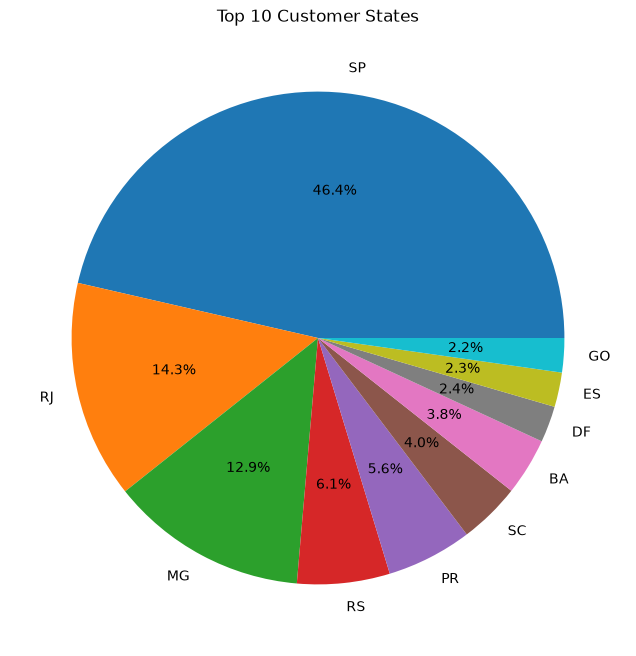

In [488]:
state_counts = customers["customer_state"].value_counts().head(10)
plt.figure(figsize=(8,8))
plt.pie(
    state_counts.values,
    labels=state_counts.index,
    autopct="%1.1f%%"
)
plt.title("Top 10 Customer States")
plt.show()

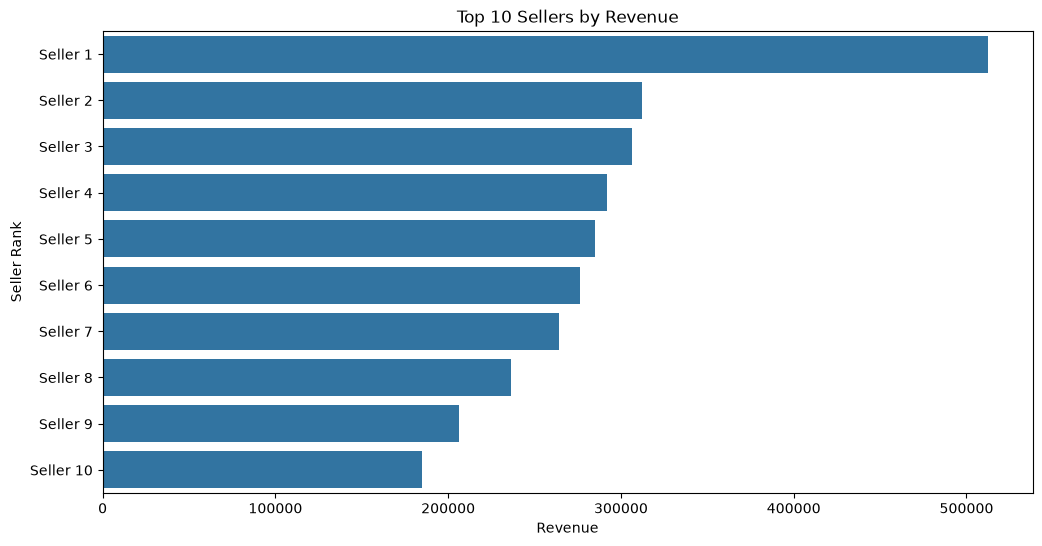

In [492]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=seller_sales,
    x="payment_value",
    y="Seller"
)
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller Rank")

plt.show()

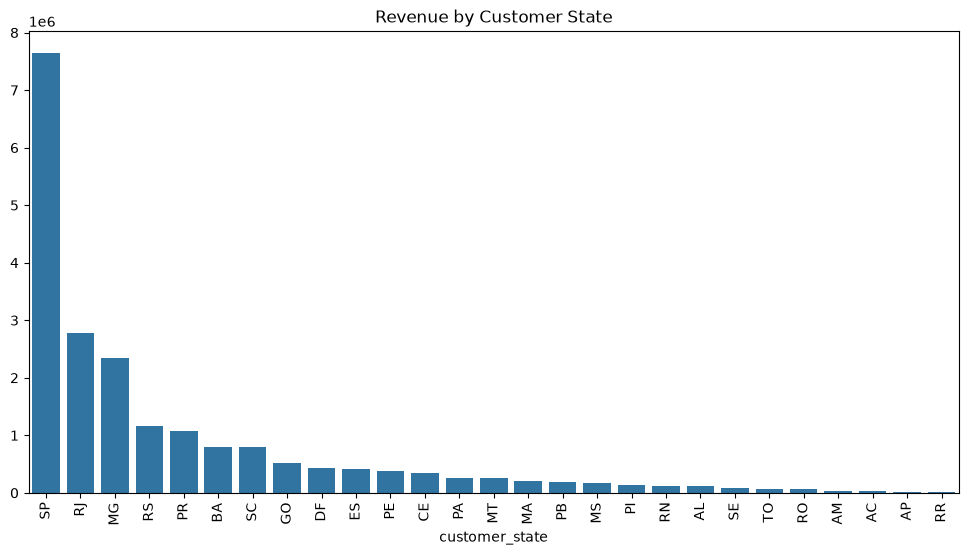

In [494]:
state_sales = (
    final_df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=state_sales.index,
    y=state_sales.values
)
plt.xticks(rotation=90)
plt.title("Revenue by Customer State")
plt.show()

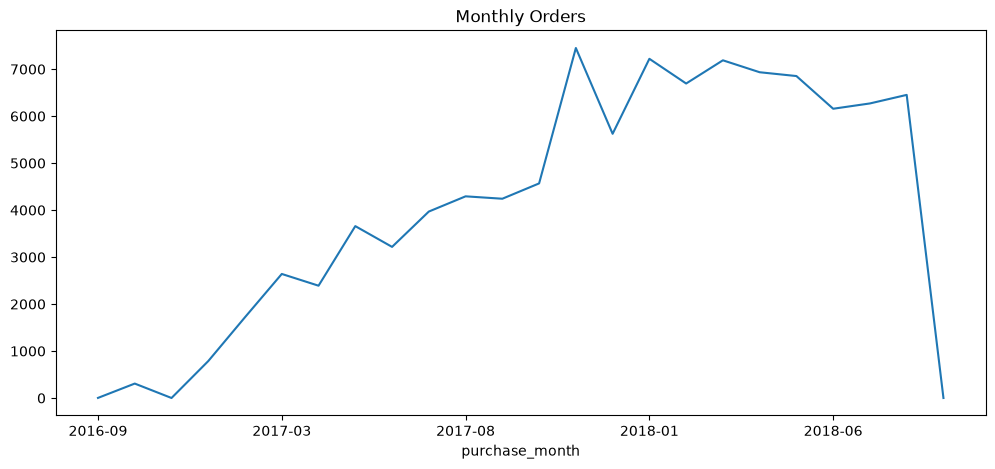

In [496]:
monthly_orders = (
    final_df.groupby("purchase_month")["order_id"]
    .nunique()
)
plt.figure(figsize=(12,5))
monthly_orders.plot()
plt.title("Monthly Orders")
plt.show()

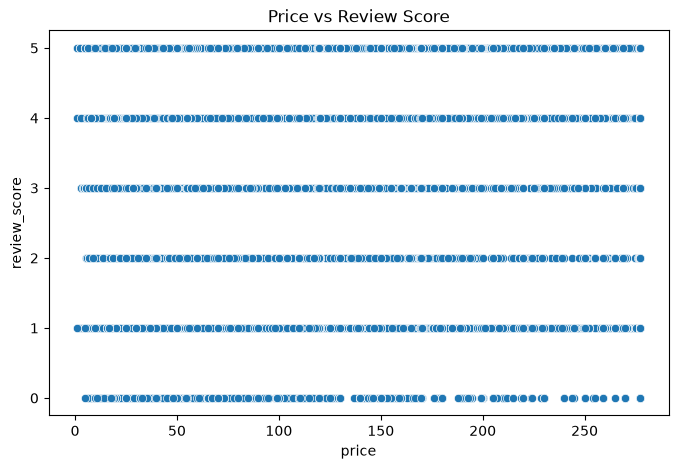

In [498]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=final_df,
    x="price",
    y="review_score"
)
plt.title("Price vs Review Score")
plt.show()

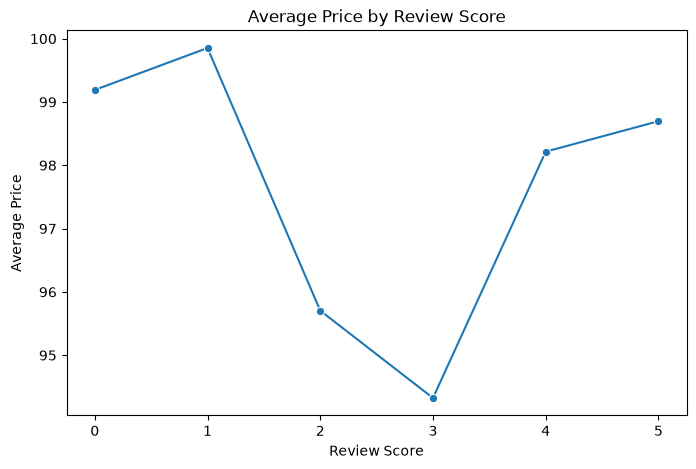

In [499]:
avg_price = final_df.groupby("review_score")["price"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(
    data=avg_price,
    x="review_score",
    y="price",
    marker="o"
)
plt.title("Average Price by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Price")
plt.show()

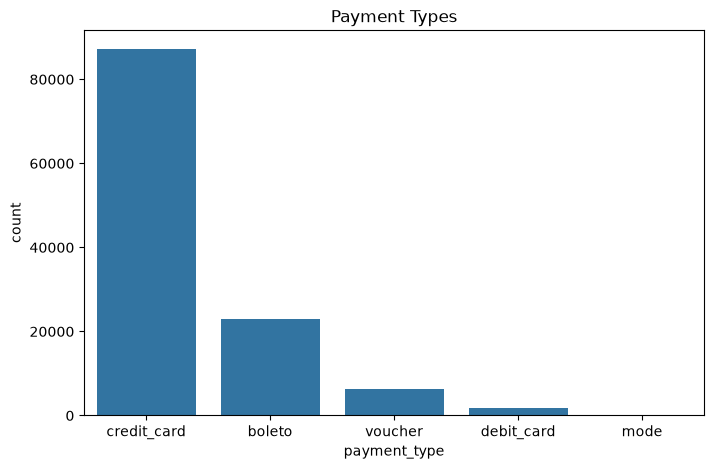

In [501]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=final_df,
    x="payment_type"
)
plt.title("Payment Types")
plt.show()

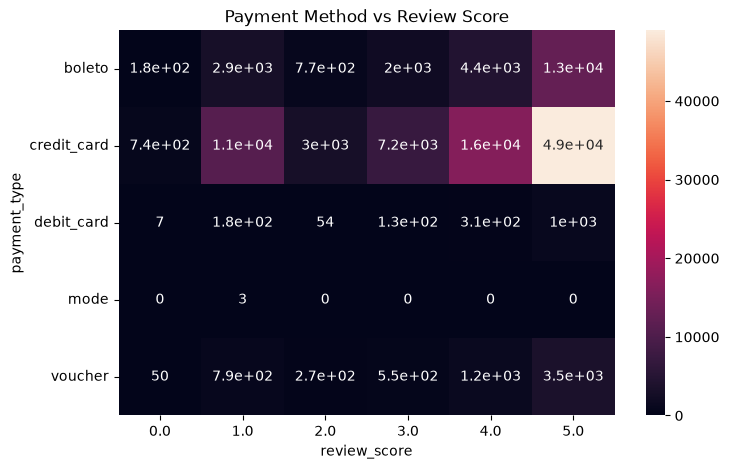

In [503]:
pivot = pd.crosstab(
    final_df["payment_type"],
    final_df["review_score"]
)
plt.figure(figsize=(8,5))
sns.heatmap(
    pivot,
    annot=True
)
plt.title("Payment Method vs Review Score")
plt.show()

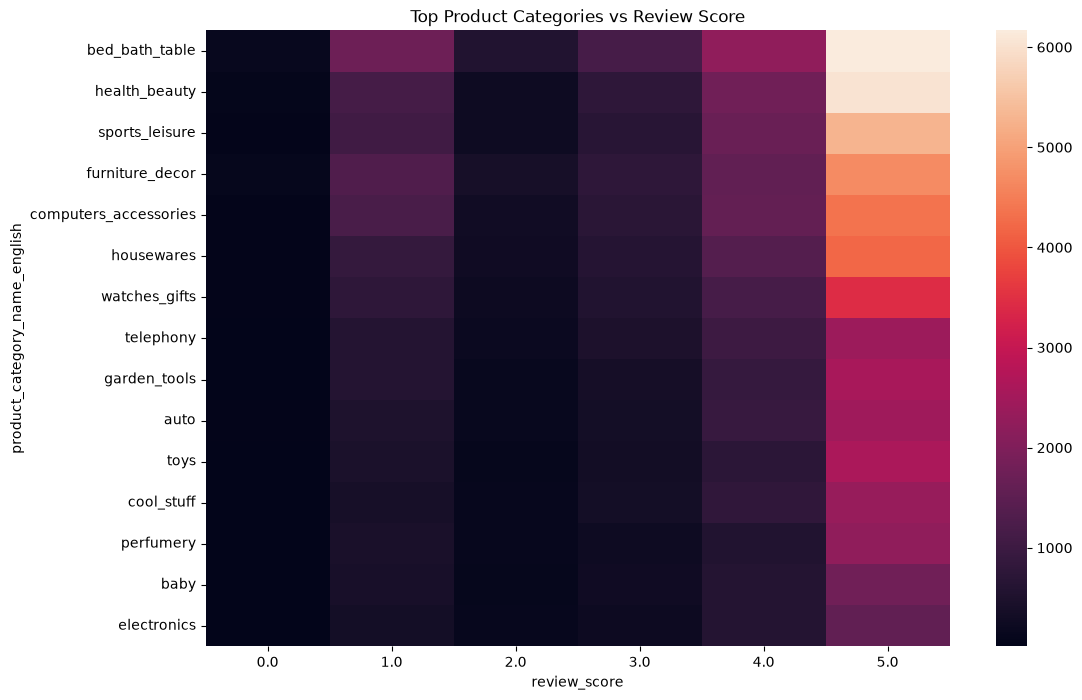

In [504]:
pivot = pd.crosstab(
    final_df["product_category_name_english"],
    final_df["review_score"]
)
pivot = pivot.loc[
    final_df["product_category_name_english"].value_counts().head(15).index
]
plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
)
plt.title("Top Product Categories vs Review Score")
plt.show()

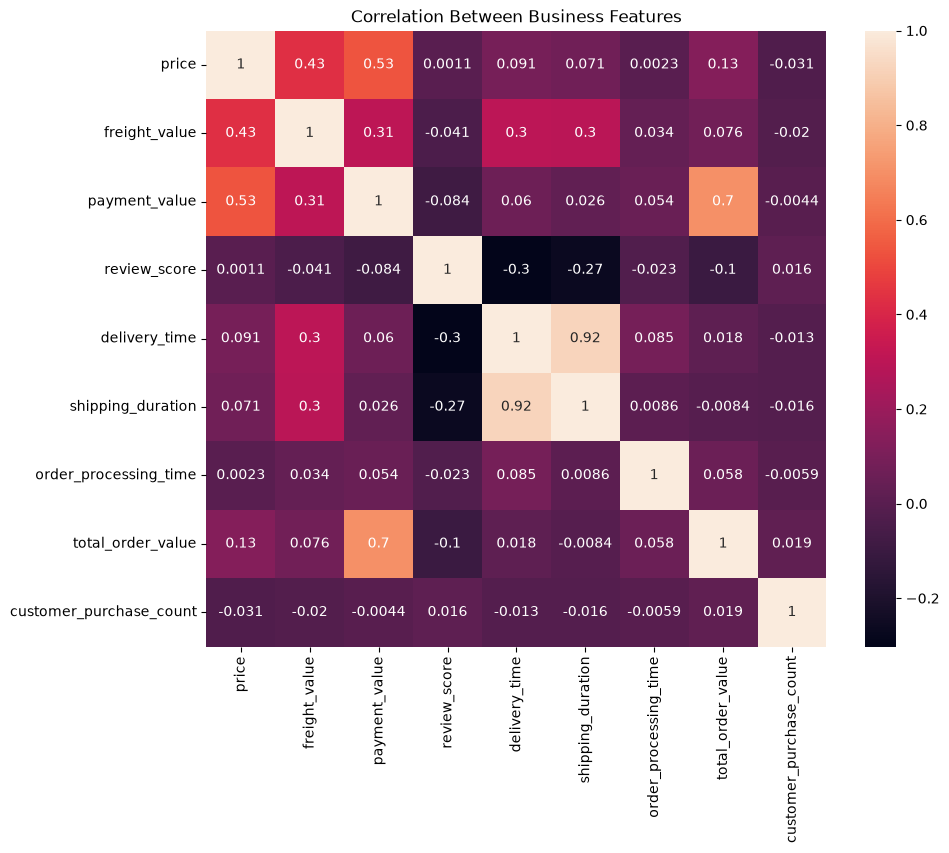

In [505]:
corr_columns = [
    "price",
    "freight_value",
    "payment_value",
    "review_score",
    "delivery_time",
    "shipping_duration",
    "order_processing_time",
    "total_order_value",
    "customer_purchase_count"
]
plt.figure(figsize=(10,8))
corr = final_df[corr_columns].corr()
sns.heatmap(
    corr,
    annot=True,
)
plt.title("Correlation Between Business Features")
plt.show()

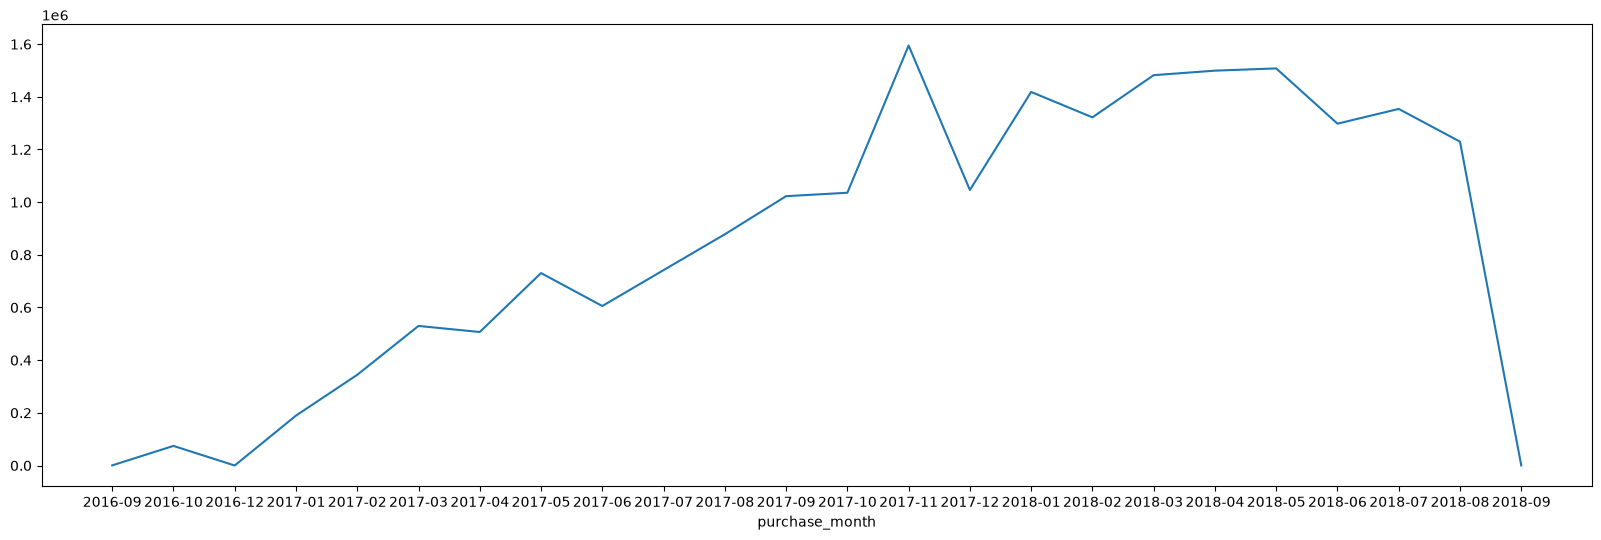

In [517]:
plt.figure(figsize=(20,6))
monthly_sales = (
    final_df.groupby("purchase_month")["payment_value"]
    .sum()
)
sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)
plt.show()

SALES

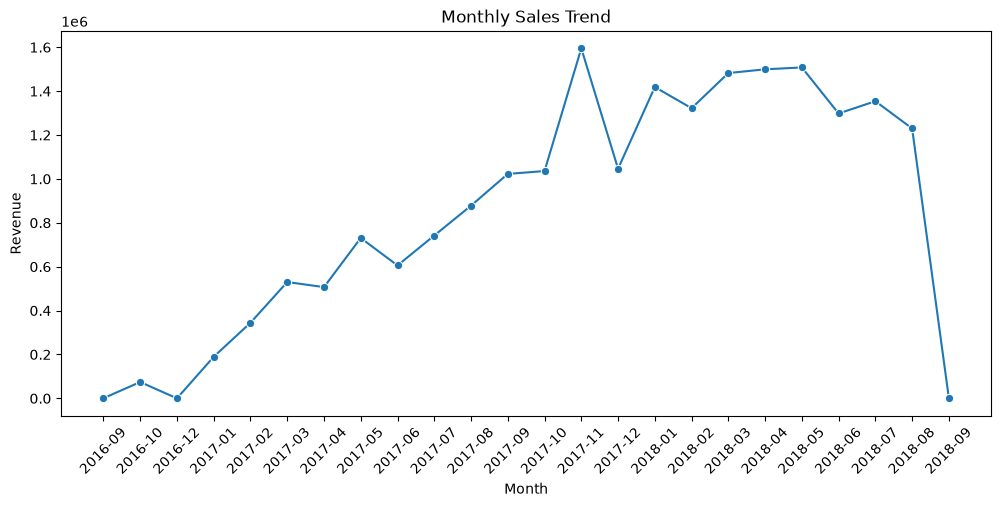

In [518]:
monthly_sales = (
    final_df.groupby("purchase_month")["payment_value"]
    .sum()
)
plt.figure(figsize=(12,5))
sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

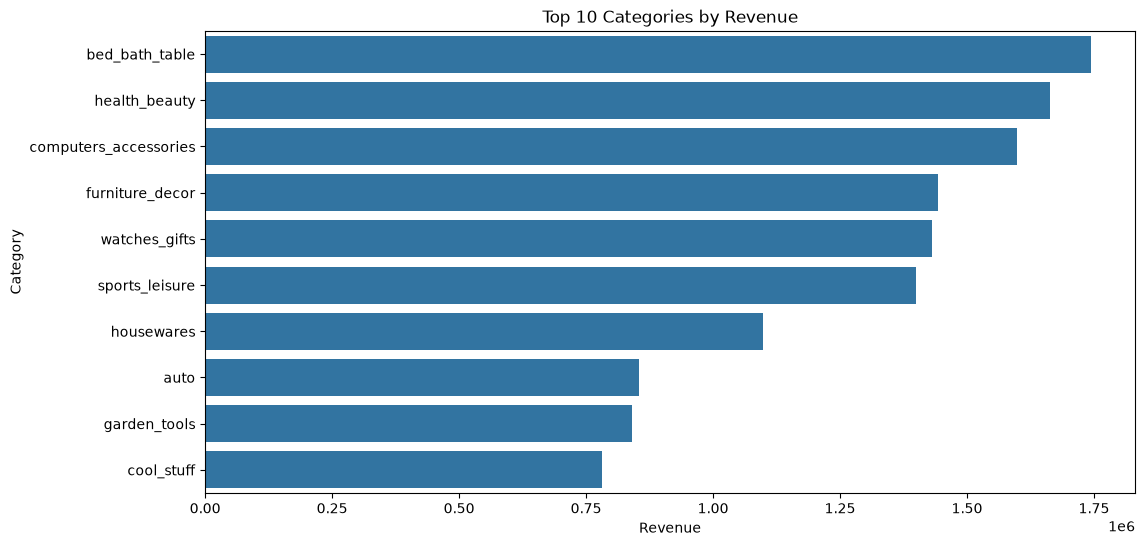

In [519]:
category_sales = (
    final_df.groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

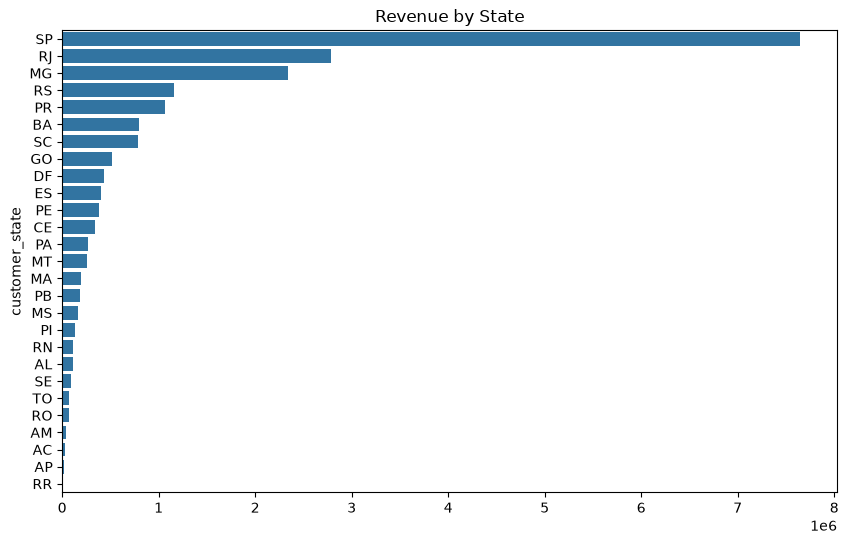

In [520]:
state_sales = (
    final_df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=state_sales.values,
    y=state_sales.index
)
plt.title("Revenue by State")
plt.show()

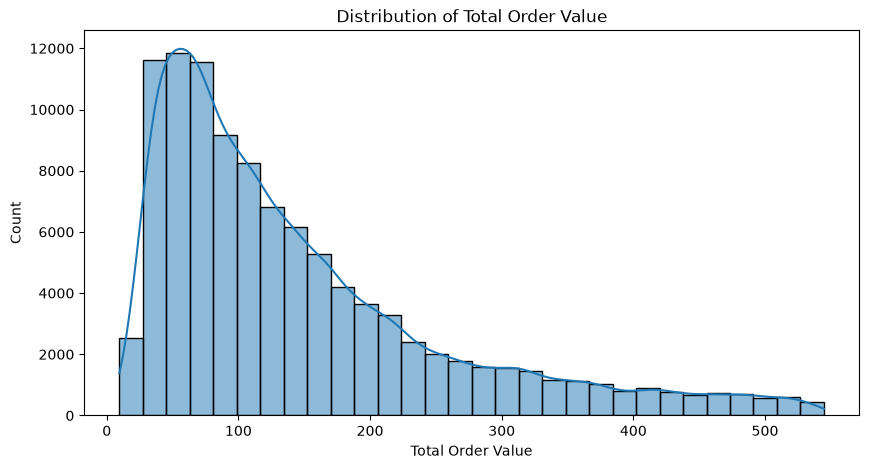

In [522]:
plt.figure(figsize=(10,5))
sns.histplot(
    filtered["total_order_value"],
    bins=30,
    kde=True
)
plt.title("Distribution of Total Order Value")
plt.xlabel("Total Order Value")
plt.show()

CUSTOMER

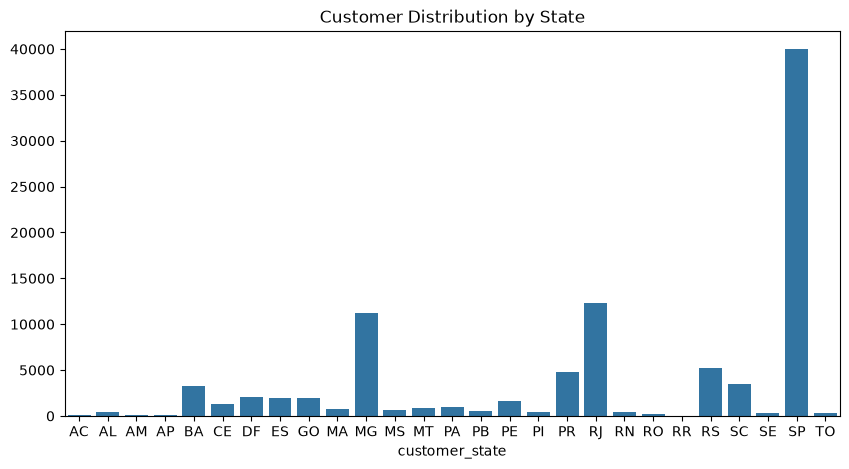

In [523]:
customer_state = (
    final_df.groupby("customer_state")["customer_unique_id"]
    .nunique()
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=customer_state.index,
    y=customer_state.values
)
plt.title("Customer Distribution by State")
plt.show()

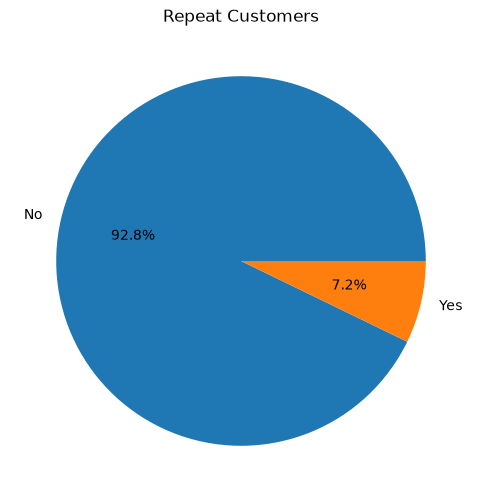

In [524]:
repeat = (
    final_df["repeat_customer"]
    .value_counts()
)
plt.figure(figsize=(6,6))
plt.pie(
    repeat,
    labels=repeat.index,
    autopct="%1.1f%%"
)
plt.title("Repeat Customers")
plt.show()

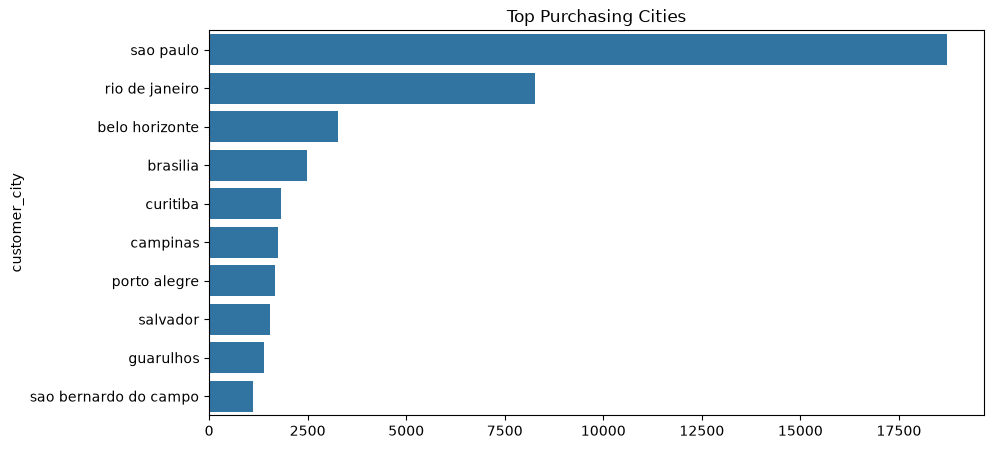

In [525]:
cities = (
    final_df.groupby("customer_city")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=cities.values,
    y=cities.index
)
plt.title("Top Purchasing Cities")
plt.show()

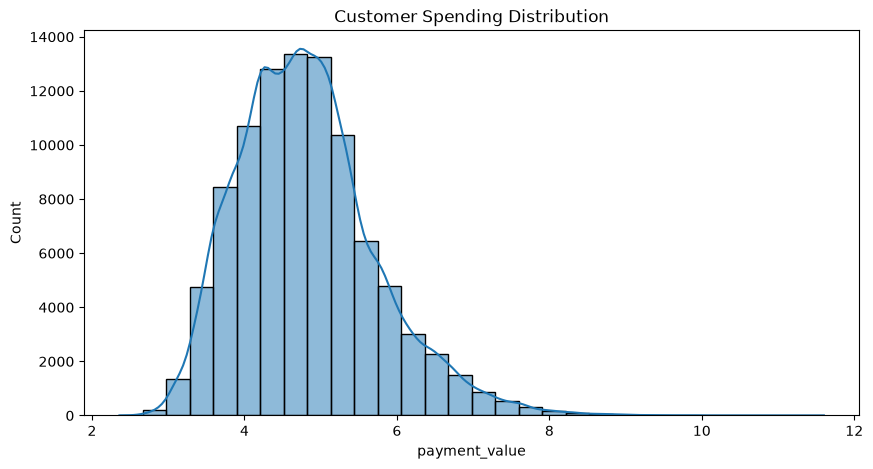

In [567]:
customer_spending = (
    final_df.groupby("customer_unique_id")["payment_value"]
    .sum()
)
plt.figure(figsize=(10,5))
sns.histplot(
    np.log1p(customer_spending),
    bins=30,
    kde=True
)
plt.title("Customer Spending Distribution")
plt.show()

PRODUCT

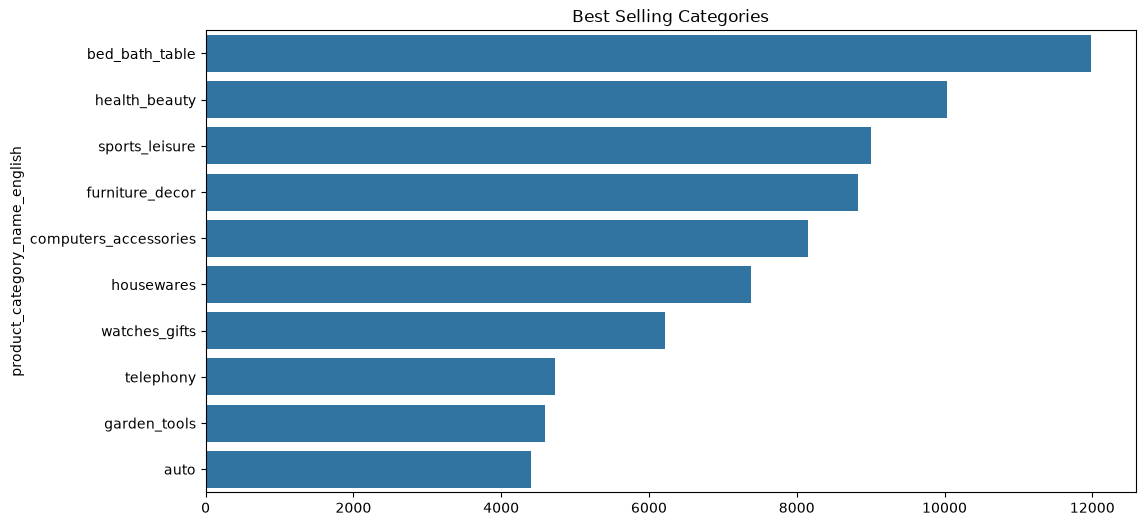

In [527]:
best_products = (
    final_df.groupby("product_category_name_english")["order_item_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=best_products.values,
    y=best_products.index
)
plt.title("Best Selling Categories")
plt.show()

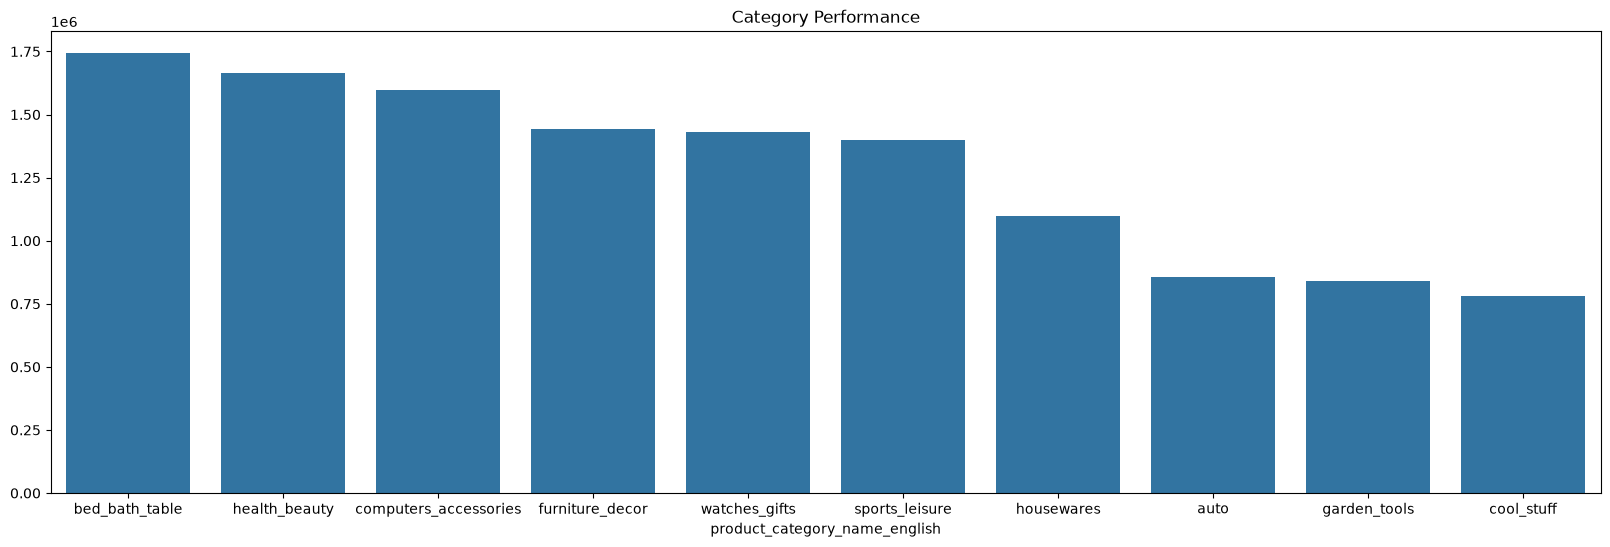

In [532]:
performance = (
    final_df.groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(20,6))
sns.barplot(
    y=performance.values,
    x=performance.index
)
plt.title("Category Performance")
plt.show()

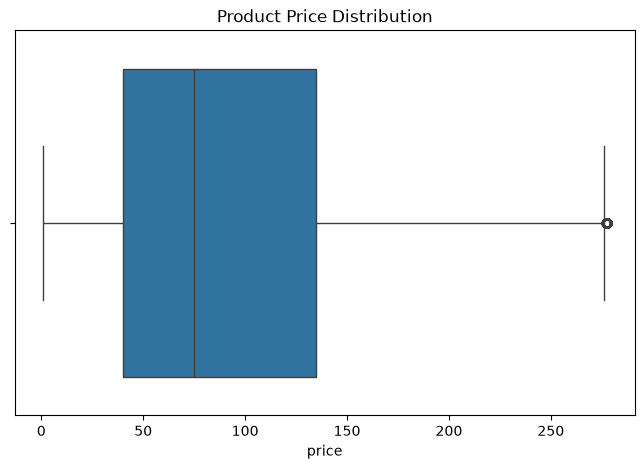

In [533]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=final_df["price"]
)
plt.title("Product Price Distribution")
plt.show()

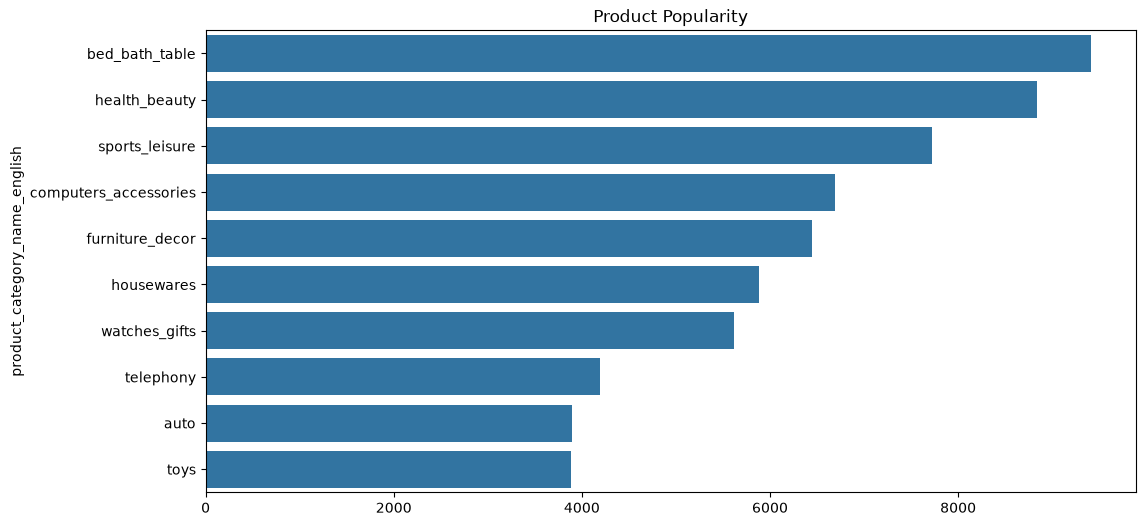

In [534]:
popularity = (
    final_df.groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=popularity.values,
    y=popularity.index
)
plt.title("Product Popularity")
plt.show()

SELLER

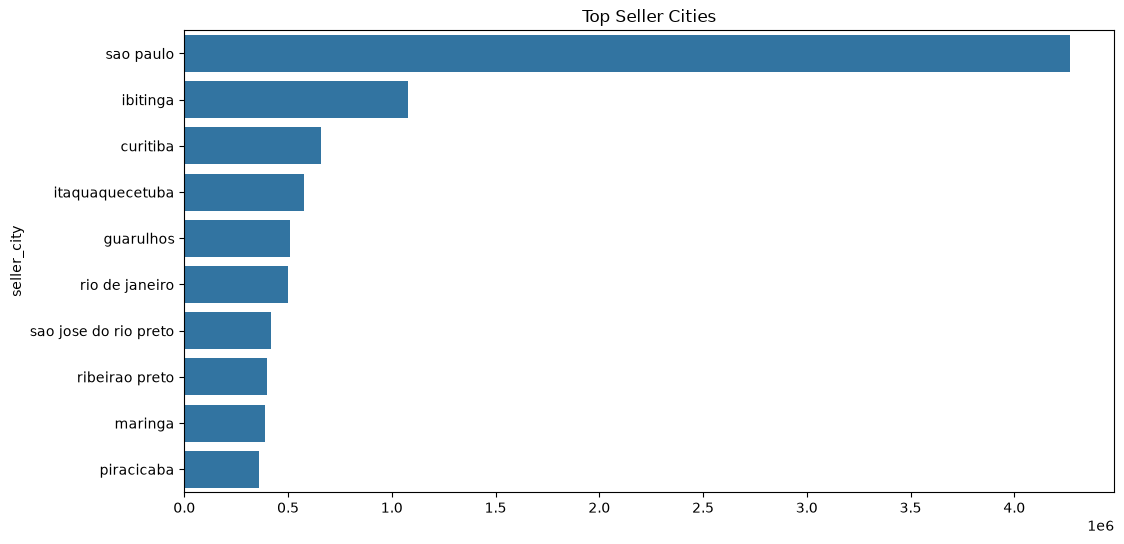

In [535]:
top_sellers = (
    final_df.groupby("seller_city")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_sellers.values,
    y=top_sellers.index
)
plt.title("Top Seller Cities")
plt.show()

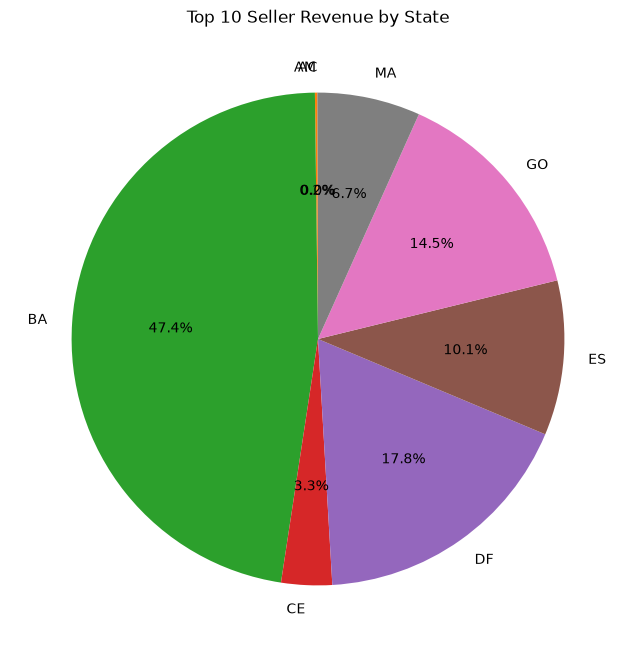

In [565]:
seller_state = (
    final_df.groupby("seller_state")["payment_value"]
    .sum()
)
top_10=seller_state.head(8)
plt.figure(figsize=(8,8))
plt.pie(top_10,
    labels=top_10.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Top 10 Seller Revenue by State")
plt.show()

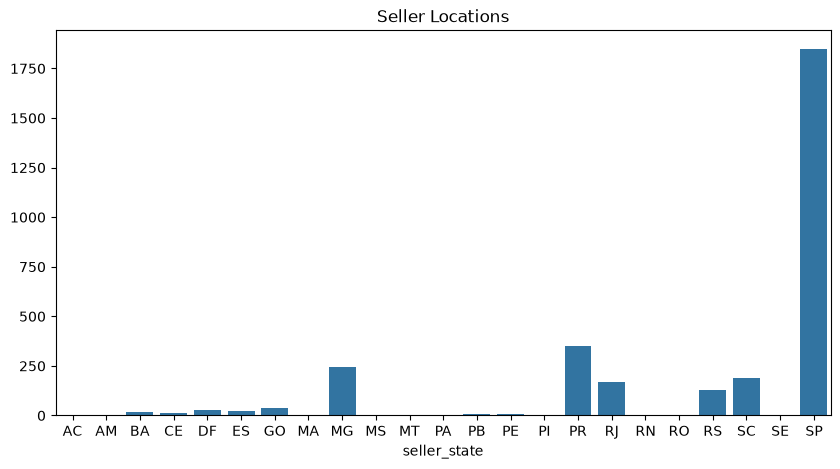

In [537]:
locations = (
    final_df.groupby("seller_state")["seller_id"]
    .nunique()
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=locations.index,
    y=locations.values
)
plt.title("Seller Locations")
plt.show()

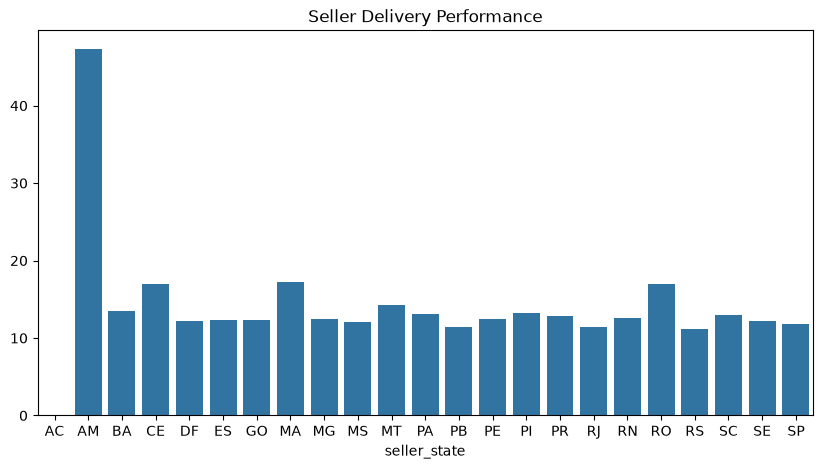

In [538]:
delivery_perf = (
    final_df.groupby("seller_state")["delivery_time"]
    .mean()
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=delivery_perf.index,
    y=delivery_perf.values
)
plt.title("Seller Delivery Performance")
plt.show()

DELIVERY

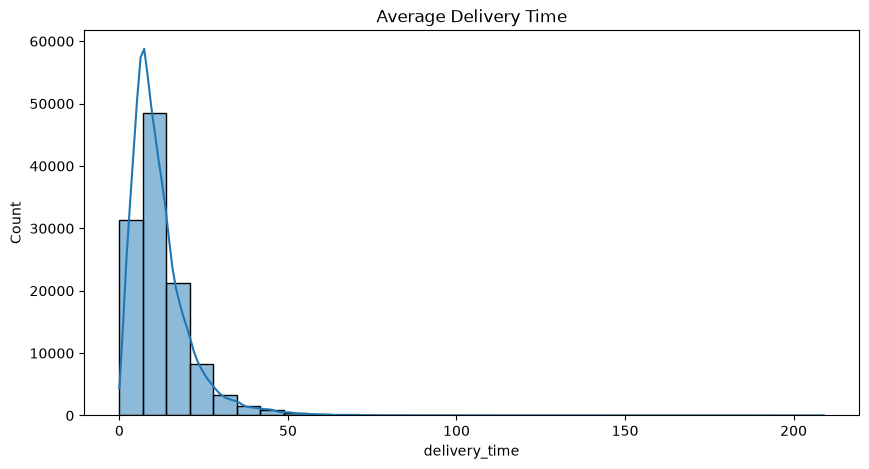

In [539]:
plt.figure(figsize=(10,5))
sns.histplot(
    final_df["delivery_time"],
    bins=30,
    kde=True
)
plt.title("Average Delivery Time")
plt.show()

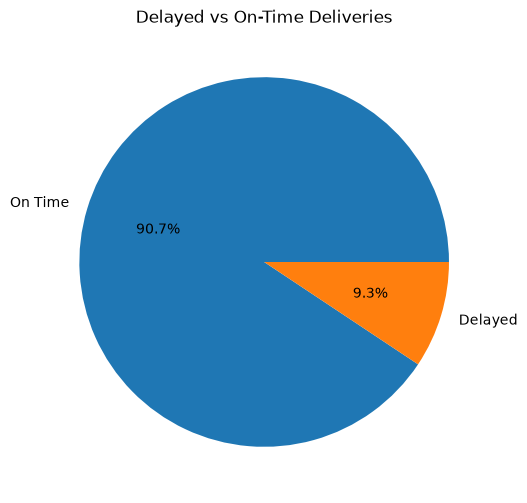

In [574]:
delay = (
    final_df["delivery_status"]
    .value_counts()
)
plt.figure(figsize=(6,6))
plt.pie(
    delay,
    labels=delay.index,
    autopct="%1.1f%%"
)
plt.title("Delayed vs On-Time Deliveries")
plt.show()

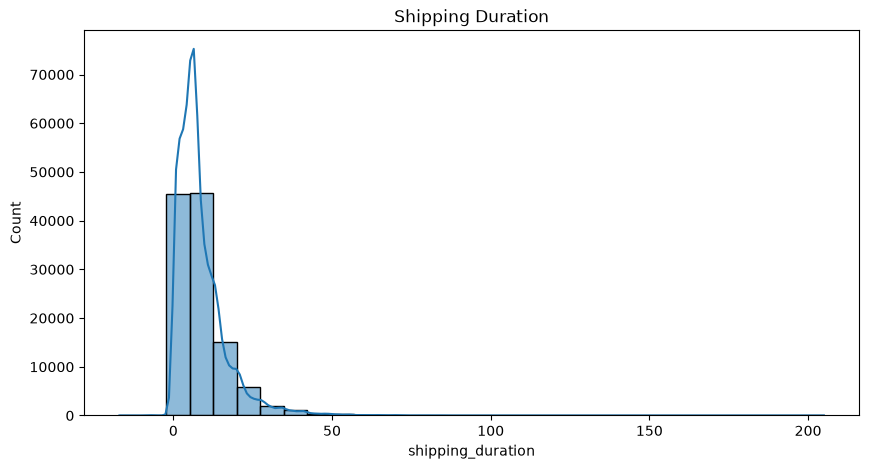

In [541]:
plt.figure(figsize=(10,5))
sns.histplot(
    final_df["shipping_duration"],
    bins=30,
    kde=True
)
plt.title("Shipping Duration")
plt.show()

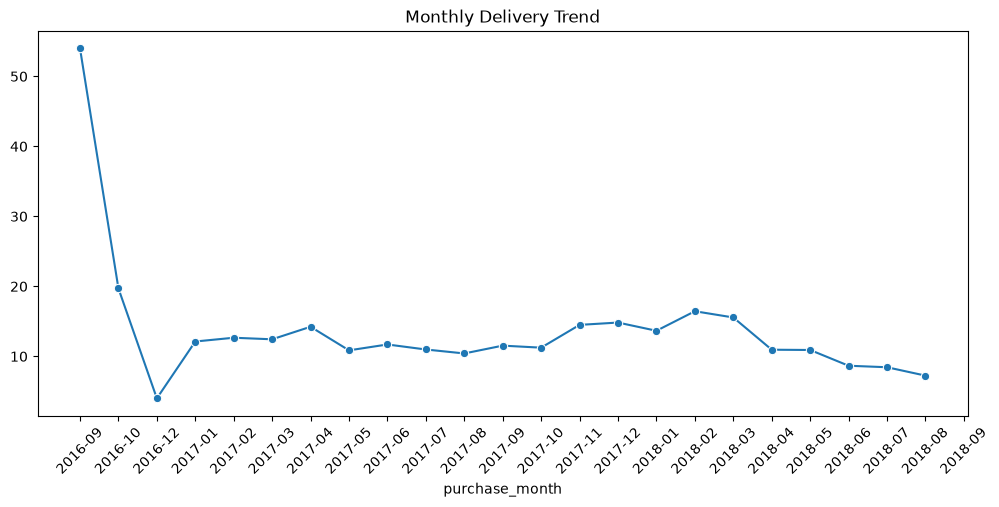

In [542]:
delivery_month = (
    final_df.groupby("purchase_month")["delivery_time"]
    .mean()
)
plt.figure(figsize=(12,5))
sns.lineplot(
    x=delivery_month.index,
    y=delivery_month.values,
    marker="o"
)
plt.title("Monthly Delivery Trend")
plt.xticks(rotation=45)
plt.show()

PAYMENT

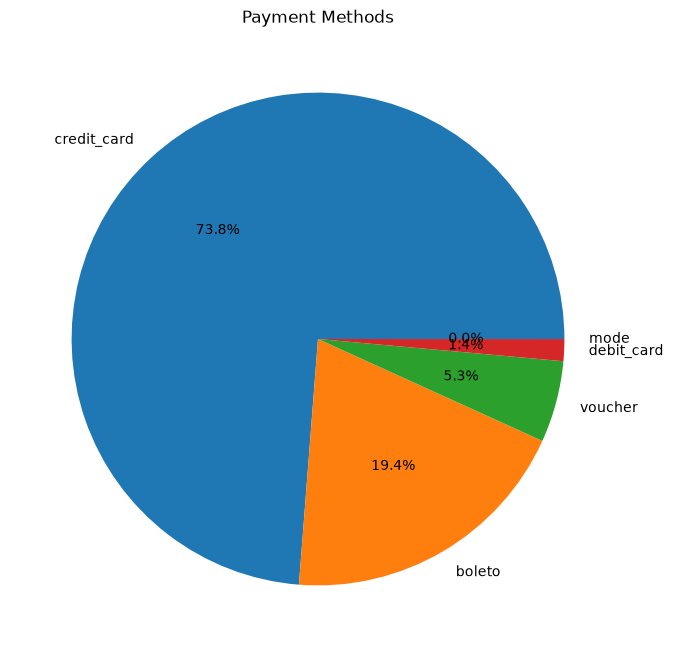

In [563]:
payment = final_df["payment_type"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(
    payment,
    labels=payment.index,
    autopct="%1.1f%%"
)
plt.title("Payment Methods")
plt.show()

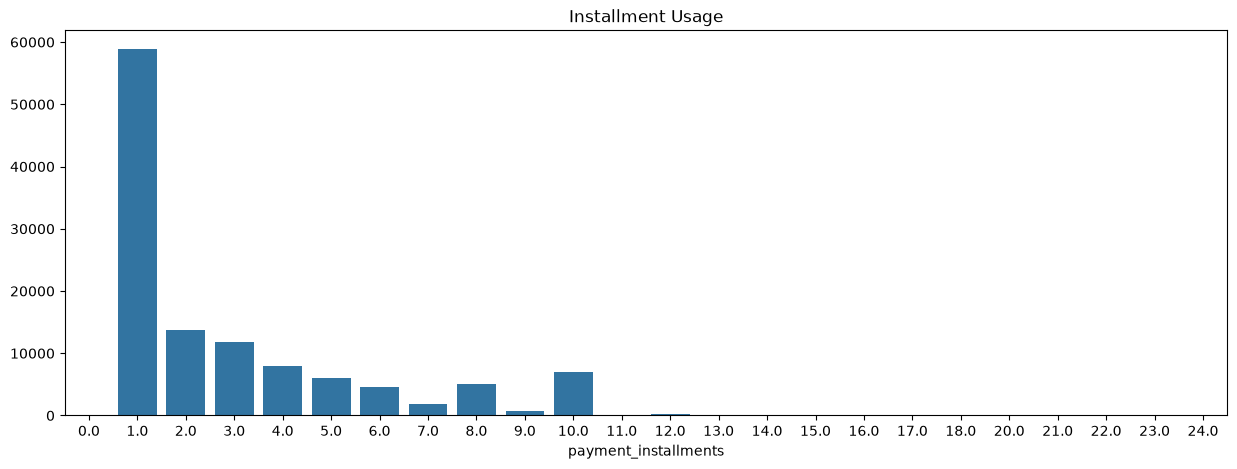

In [545]:
installments = (
    final_df["payment_installments"]
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(15,5))
sns.barplot(
    x=installments.index,
    y=installments.values
)
plt.title("Installment Usage")
plt.show()

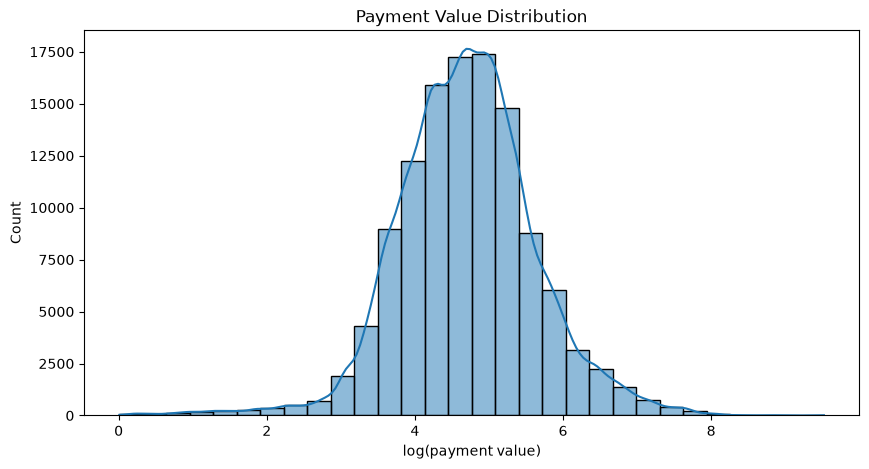

In [562]:
plt.figure(figsize=(10,5))
sns.histplot(
    np.log1p(final_df["payment_value"]),
    bins=30,
    kde=True
)
plt.title("Payment Value Distribution")
plt.xlabel("log(payment value)")
plt.show()

REVIEW

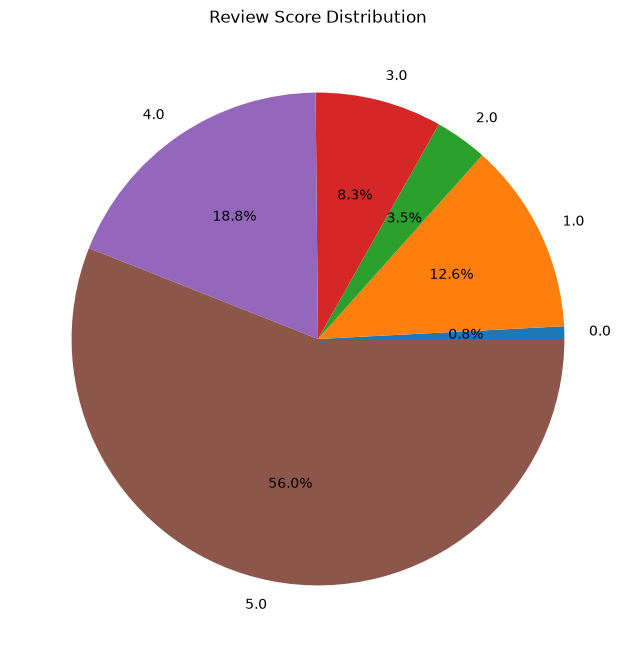

In [552]:
plt.figure(figsize=(8,8))
review_counts = final_df["review_score"].value_counts().sort_index()
plt.pie(
    review_counts,
    labels=review_counts.index,
    autopct="%1.1f%%",
)
plt.title("Review Score Distribution")
plt.show()

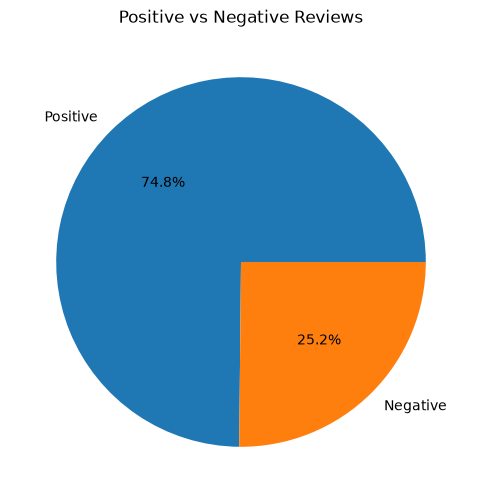

In [548]:
final_df["review_type"] = np.where(
    final_df["review_score"] >= 4,
    "Positive",
    "Negative"
)
review_type = (
    final_df["review_type"]
    .value_counts()
)
plt.figure(figsize=(6,6))
plt.pie(
    review_type,
    labels=review_type.index,
    autopct="%1.1f%%"
)
plt.title("Positive vs Negative Reviews")
plt.show()

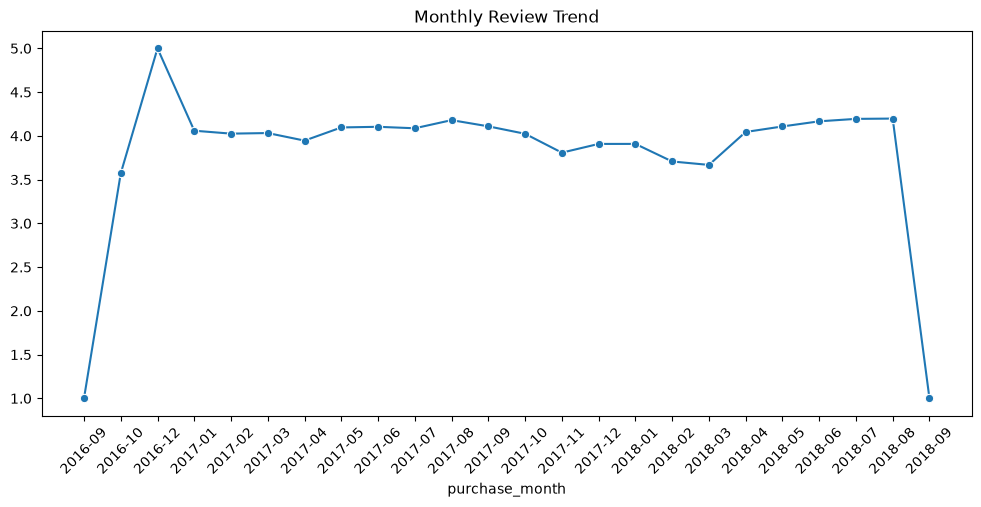

In [549]:
review_trend = (
    final_df.groupby("purchase_month")["review_score"]
    .mean()
)
plt.figure(figsize=(12,5))
sns.lineplot(
    x=review_trend.index,
    y=review_trend.values,
    marker="o"
)
plt.title("Monthly Review Trend")
plt.xticks(rotation=45)
plt.show()

In [575]:
final_df.to_csv(
    "feature_engineered_dataset.csv",
    index=False
)